# Auswertung zur Diplomarbeit

## Import der notwendigen Packages

In [1]:
from decorator import decorate
from pandas import pivot_table
%matplotlib inline

from pathlib import Path
import contextily as cx
import geopandas as gpd
import pandas as pd
import shapely.geometry as shp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import geodatasets
import numpy as np

import diplomarbeit as da

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

import scipy.optimize as opt

import seaborn as sns

import osmnx as ox

import matplot2tikz

## Definition von Variablen und Pfaden

In [2]:
RESULTS_DIR = Path('./results')  # TODO: Make LaTeX-Picture directory for Production

sns.set_theme()
#plt.rc('font', family='serif', size=11)
#plt.rc('text', usetex=True)

cm = 1/2.54

da.set_print_style(16,10)

## Laden des Datasets

In [3]:
data=gpd.read_file(da.DATA_DIR / 'building_data.json').dropna(axis='index').reset_index(drop=True)
data

df_orientations = data[['Stadt', 'phi_street', 'phi_tram', 'distance', 'region']].groupby('Stadt').aggregate({'phi_street':'first','phi_tram':'first', 'distance': 'sum', 'region':'first'})
df_orientations

,phi_street,phi_tram,distance,region
Stadt,,,,
Amsterdam,0.080535,0.082987,259.168810,Westeuropa
Antwerpen,0.026045,0.024597,224.978935,Westeuropa
Berlin,0.010457,0.033647,475.814975,DACH
Bordeaux,0.015978,0.123866,295.241180,Westeuropa
Brandenburg a. d. Havel,0.022597,0.082082,32.482947,DACH
Brüssel,0.037062,0.184850,233.472199,Westeuropa
Budapest,0.049933,0.017622,610.528710,Zentraleuropa
Bukarest,0.010302,0.021254,200.703236,Südosteuropa
Den Haag,0.245209,0.095171,315.990211,Westeuropa


### Gruppieren der Städte

In [4]:
def weighted_average(data:pd.DataFrame, value, weight):
    val = data[value]
    wt = data[weight]
    return (val * wt).sum() / wt.sum()

In [5]:
agg_func = {'distance': ['mean', 'sum'],
            #'trip_speed': ['mean'],
            'number_trips': ['sum'],
            'curvature': ['mean', 'min','max'],
            'avg_dist': ['mean'],
            'rho_b': ['mean'],
            'machine_readable': ['count'],
            'Stadt': 'first',
            'ISO3166': 'first',
            'gauge': 'first',
           'region':'first',
            'Buffer_Width':'mean'}
df_cities_grouped = data[['Stadt', 'distance', 'trip_speed', 'number_trips', 'curvature', 'avg_dist', 'rho_b', 'gauge', 'ISO3166',
                    'machine_readable', 'region', 'Buffer_Width']].groupby(by=['ISO3166', 'Stadt']).aggregate(func=agg_func)
df_cities_grouped['trip_speeds_new']=data.groupby(['ISO3166', 'Stadt']).apply(weighted_average, 'trip_speed', 'number_trips')
df_cities_grouped.rename(columns={'machine_readable': 'Anzahl Relationen'}, inplace=True)
df_cities_grouped.rename_axis(['ISO3166', 'Stadt']).reset_index(inplace=True)
df_cities_grouped.columns = df_cities_grouped.columns.droplevel(1)
df_cities_grouped.describe()

/tmp/ipykernel_33617/67089698.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_cities_grouped['trip_speeds_new']=data.groupby(['ISO3166', 'Stadt']).apply(weighted_average, 'trip_speed', 'number_trips')


,distance,distance,number_trips,curvature,curvature,curvature,avg_dist,rho_b,Anzahl Relationen,gauge,Buffer_Width,trip_speeds_new
count,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.00000,41.000000,41.000000
mean,11.268488,288.180609,12497.731707,164.717274,101.044335,249.320147,482.556322,23.511749,24.682927,1312.00000,85.026658,17.452347
std,3.471982,240.134393,15549.997982,57.003627,57.447033,78.196162,136.225267,6.313543,18.415264,209.72625,15.355880,3.747322
min,7.420319,32.482947,746.000000,72.170823,15.326808,121.698120,282.463094,11.092352,4.000000,900.00000,59.754241,10.136320
25%,8.849096,121.208104,2828.000000,118.080886,54.226055,185.011458,428.987807,20.189199,12.000000,1000.00000,74.045911,15.224986
50%,10.132915,224.978935,7067.000000,161.302037,92.964218,235.862161,458.925046,22.593556,21.000000,1435.00000,83.226187,17.373675
75%,11.991356,364.510698,16476.000000,191.683312,139.094957,293.297186,505.625998,26.673776,32.000000,1435.00000,94.072147,19.405199
max,22.873098,969.741123,80703.000000,335.535737,227.250354,483.888051,1078.110952,37.017636,66.000000,1524.00000,129.472409,26.829663


/tmp/ipykernel_33617/2463411869.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


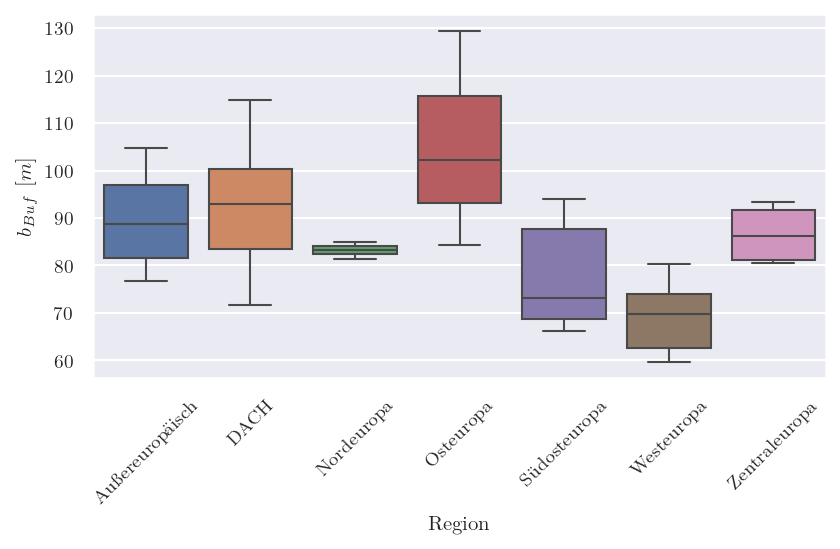

In [44]:
order=list(data['region'].unique())
order.sort()


fig, ax = plt.subplots(1,1)
sns.boxplot(df_cities_grouped, x='region', y='Buffer_Width', hue='region', hue_order=order, order=order, ax=ax)
plt.ylabel(da.COLUMN_NAMES_TEX['Buffer_Width'])
plt.xlabel('Region')
#plt.ylim(0,1000)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
fig.savefig(RESULTS_DIR/'Verteilungen'/'buffer_width_boxplot.png', dpi=600, bbox_inches='tight')

In [7]:
da.COLUMN_NAMES_TEX['Buffer_Width']

'$b_{Buf}$ $[m]$'

## Auswertung



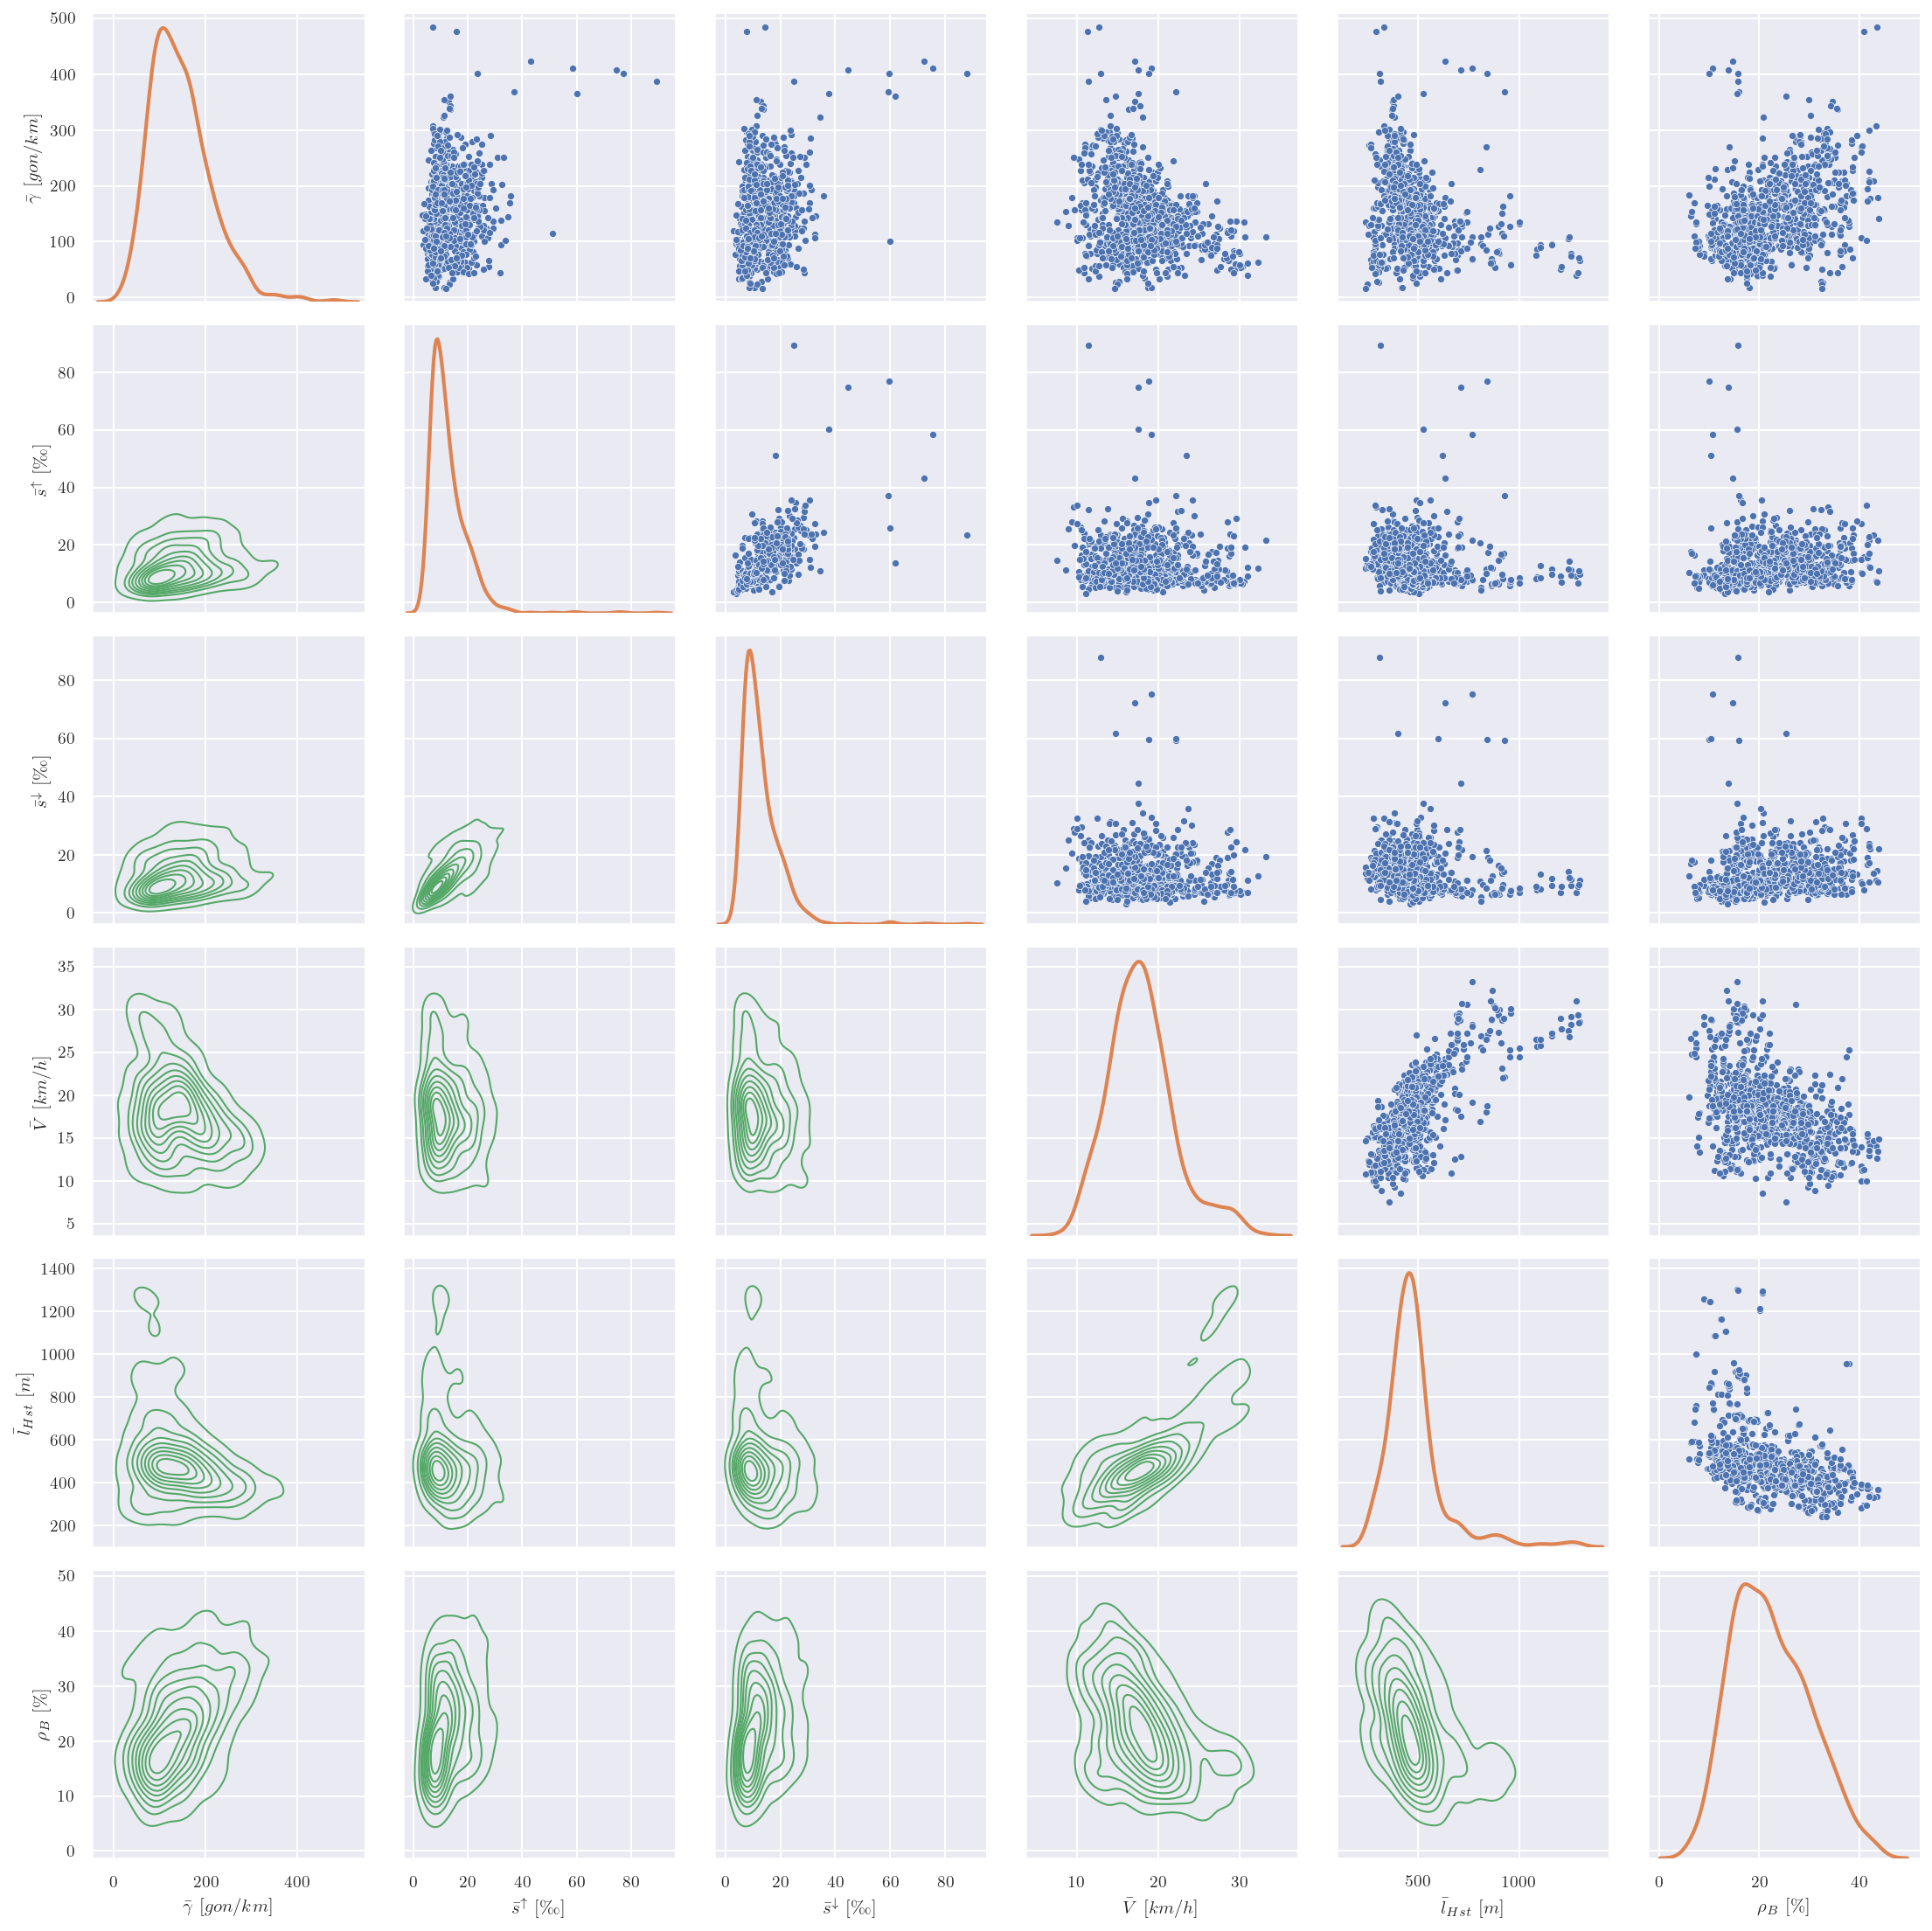

In [8]:
data_tex = data[['curvature', 'height_up', 'height_down', 'trip_speed', 'avg_dist', 'rho_b']].rename(
        columns=da.COLUMN_NAMES_TEX)

g = sns.PairGrid(data=data_tex.dropna(axis=0), diag_sharey=False)
g.map_upper(sns.scatterplot, s=15, color='C0')
g.map_diag(sns.kdeplot, lw=2, color='C1')
g.map_lower(sns.kdeplot, linewidths=1, color='C2')

### Violinplots der Parameter

/tmp/ipykernel_33617/3905552534.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_33617/3905552534.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_33617/3905552534.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_33617/3905552534.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_33617/3905552534.py:17: UserWarning: set_ticklabels() should only be used with a fixed number

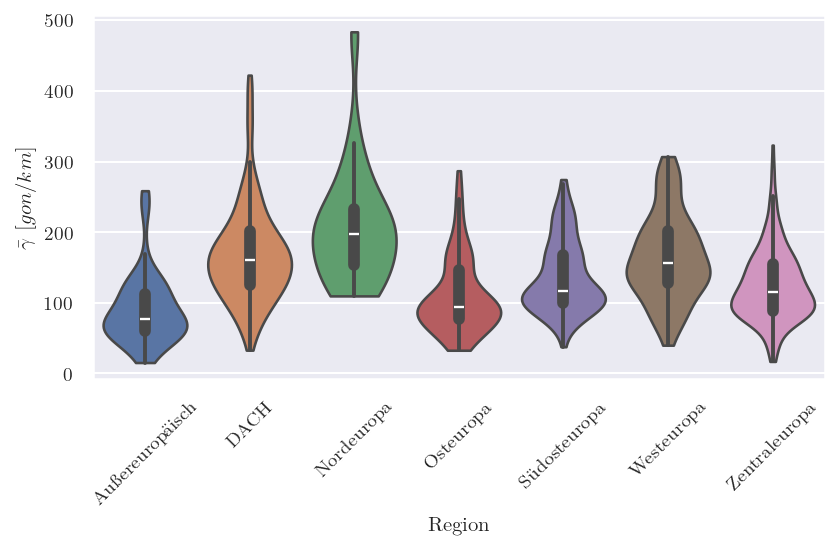

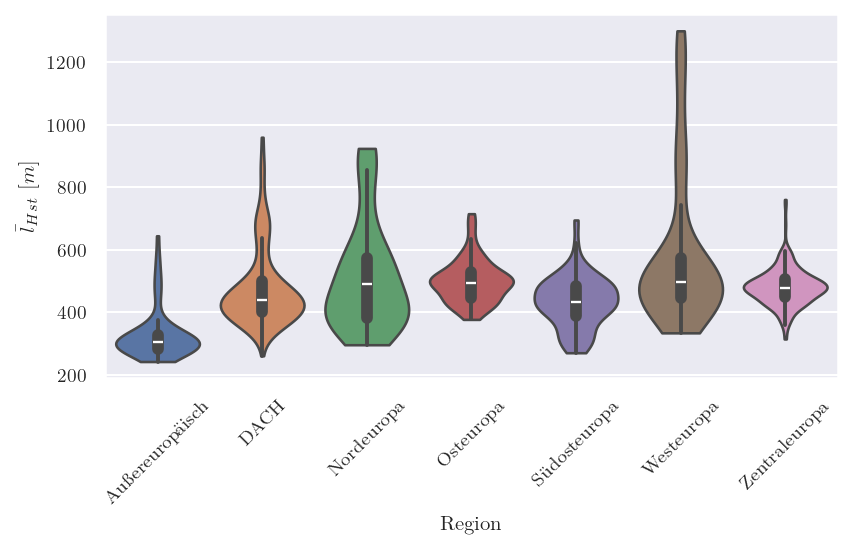

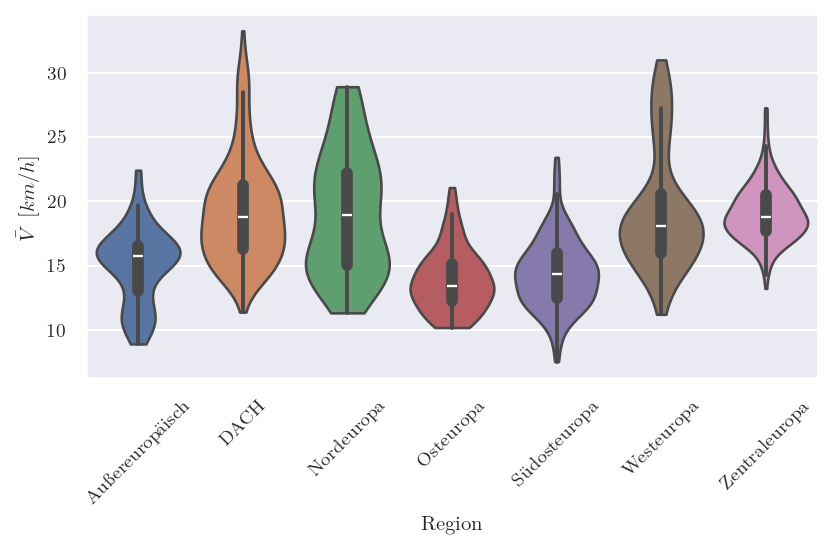

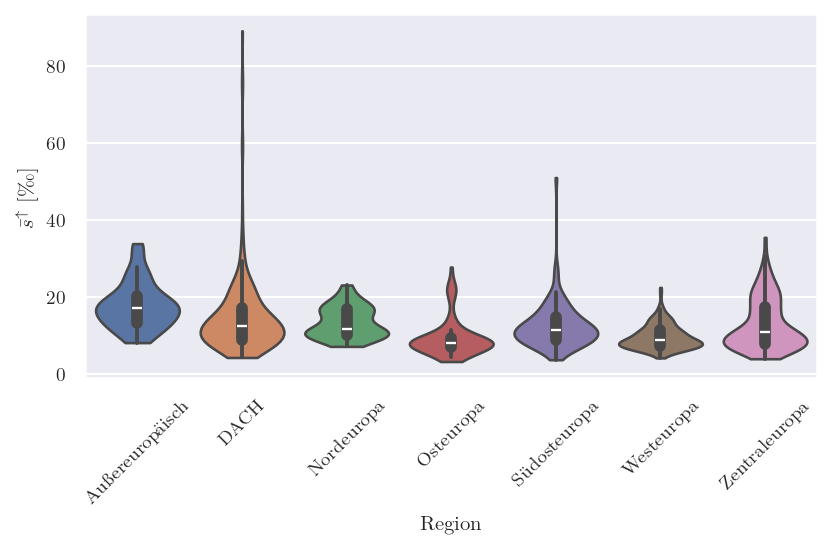

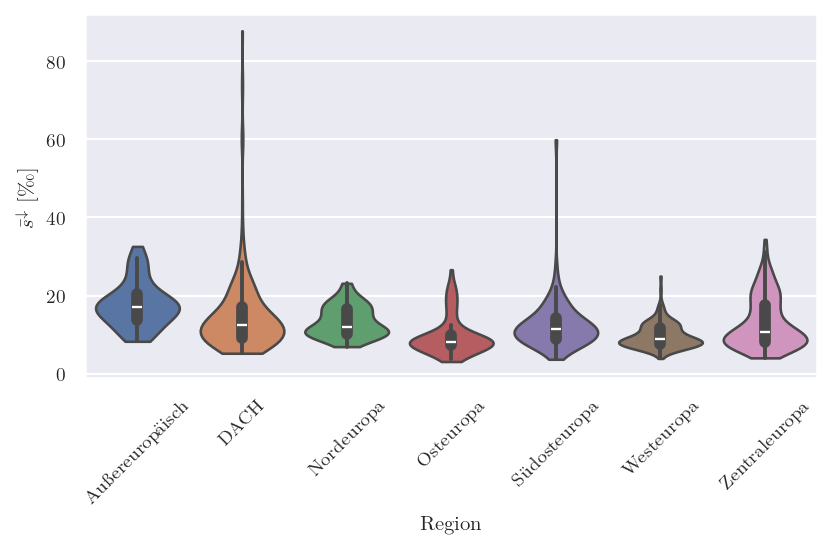

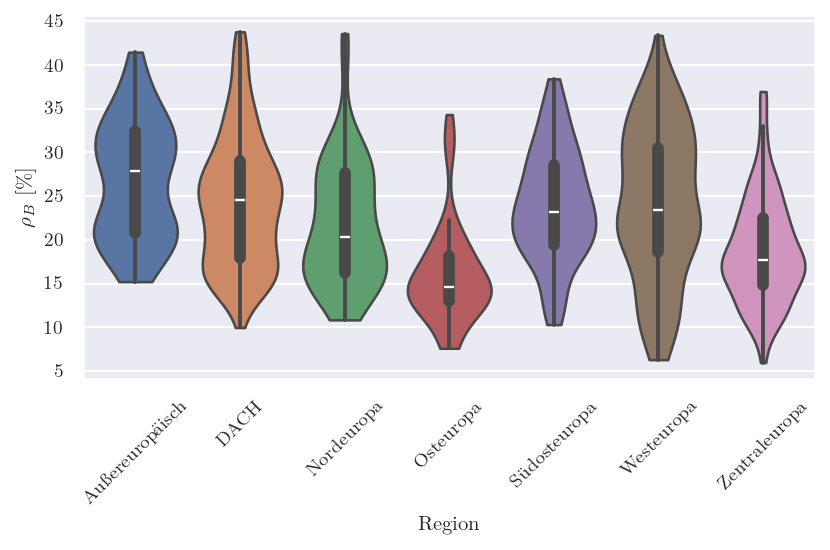

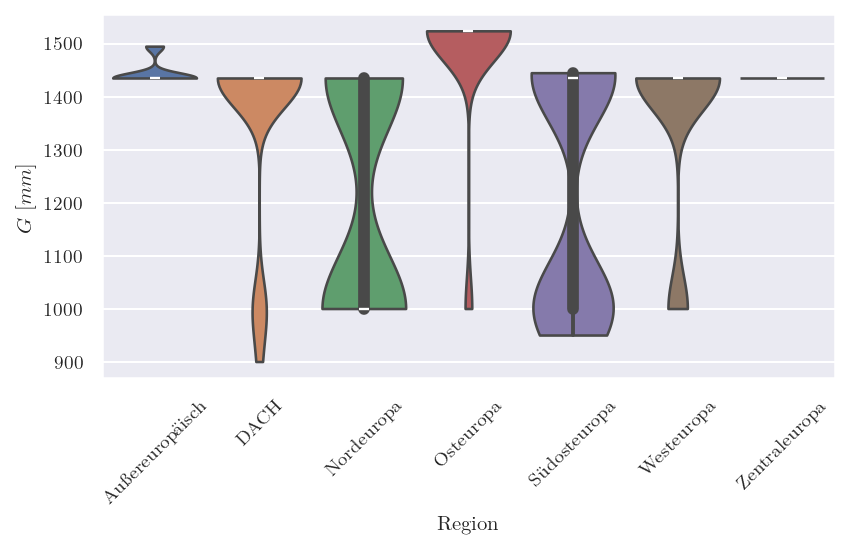

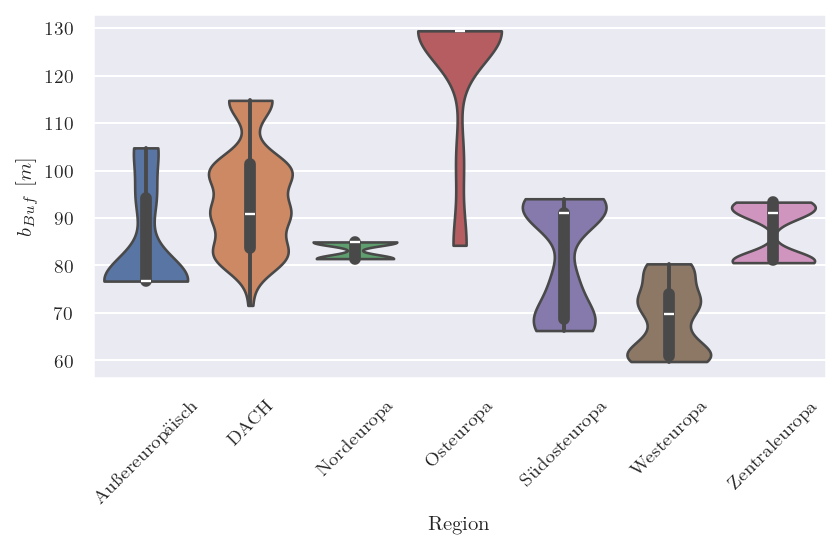

In [9]:
sns.set_theme()
#plt.rc('font', family='serif', size=11)
#plt.rc('text', usetex=True)
da.set_print_style()



for value in da.COLUMN_NAMES_DE:
    #value='avg_dist'
    filename=value+'.png'
    filename_tex=value+'.tex'

    fig, ax = plt.subplots(1,1)
    sns.violinplot(data=data.dropna(axis='index'), y=value, x='region', hue='region', cut=0, hue_order=order, order=order, ax=ax)
    plt.ylabel(da.COLUMN_NAMES_TEX[value])
    plt.xlabel('Region')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


    plt.savefig(RESULTS_DIR / 'Verteilungen' / filename, dpi=600, bbox_inches='tight')

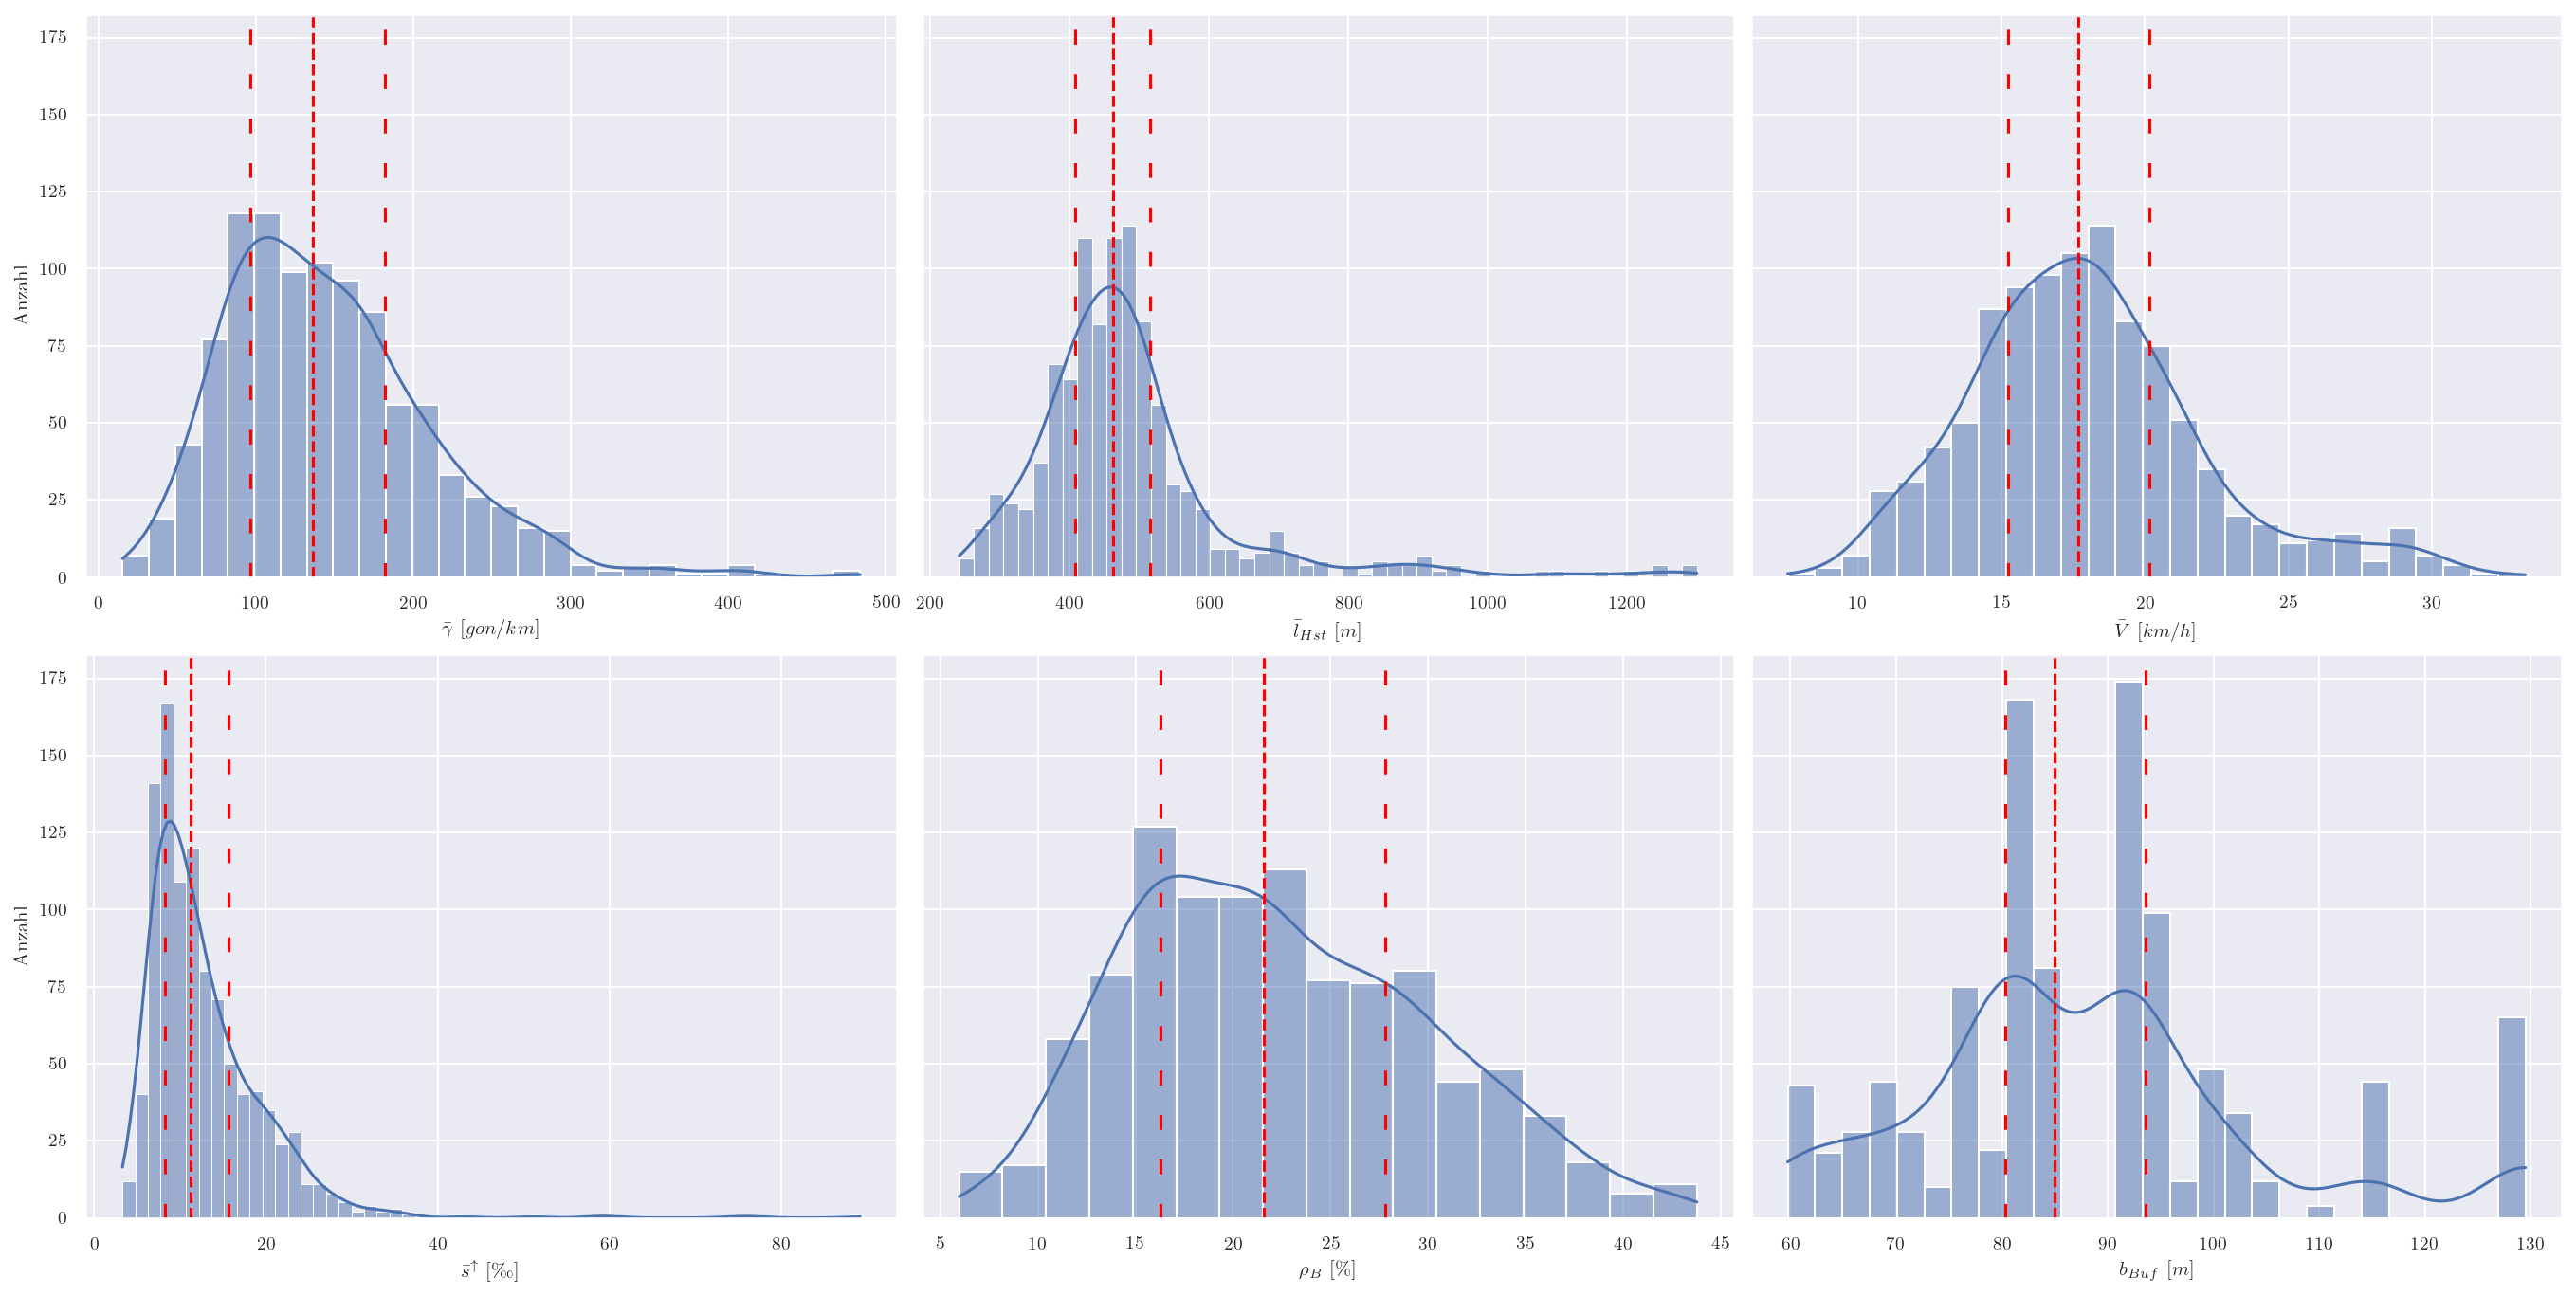

In [10]:
val_list=list(da.COLUMN_NAMES_TEX.keys())
val_list.pop(val_list.index('gauge'))
#val_list.pop(val_list.index('height_up'))
val_list.pop(val_list.index('height_down'))
n = len(val_list)
ncols = int(np.ceil(np.sqrt(n)))
nrows = int(np.ceil(n / ncols))
figsize = (ncols * 6, nrows * 4.5)
fig, axes=plt.subplots(nrows, ncols, figsize=figsize, layout='constrained', sharey=True)

for ax, value in zip(axes.flat, val_list):
    sns.histplot(data, x=value,ax=ax, kde=True)
    ax.axvline(x=data[value].median(), color='red', ls='--')
    ax.axvline(x=data[value].quantile(0.25),
                color='red',
               ls=(0, (5, 10)))
    ax.axvline(x=data[value].quantile(0.75),
                color='red',
              ls=(0, (5, 10)))
    ax.set_xlabel(da.COLUMN_NAMES_TEX[value])
    ax.set_ylabel('Anzahl')

In [11]:
data[(data['height_up']>data['height_up'].quantile(0.95))].dropna(axis='index')[['Stadt', 'line_name','height_up']].sort_values(by='height_up', ascending=False) #& (data['region']=='Westeuropa')

,Stadt,line_name,height_up
431,Linz,50: Hauptplatz - Pöstlingberg,89.217482
338,Innsbruck,Tram STB: Innsbruck => Fulpmes,76.964968
339,Innsbruck,Tram STB: Innsbruck => Mutters,74.662570
336,Innsbruck,Tram 6: Innsbruck Mühlauer Brücke => Igls,60.177657
337,Innsbruck,Tram STB: Fulpmes => Innsbruck,58.443845
973,Zagreb,Tram 15: Mihaljevac => Gračansko Dolje,51.101259
340,Innsbruck,Tram STB: Mutters => Innsbruck,43.213692
335,Innsbruck,Tram 6: Igls Bahnhof => Innsbruck Bergisel,36.968037
802,Stuttgart,U15: Stammheim => Ruhbank (Fernsehturm),35.702875
183,Budapest,56A => Budagyöngye,35.565188


### Violinplot Höhen

In [12]:
df_height=data.dropna(axis=1)
df_height = df_height.melt(value_vars=['height_up', 'height_down'], id_vars=['line_name', 'region', 'Stadt'])
df_height['variable'] = df_height['variable'].apply(lambda x: da.COLUMN_NAMES_TEX_SHORT['height_up'] if x=='height_up' else da.COLUMN_NAMES_TEX_SHORT['height_down'])
df_height

,line_name,region,Stadt,variable,value
0,Tram 12: Amsterdam Amstelstation => Amsterdam ...,Westeuropa,Amsterdam,$\bar s^{\uparrow}$,7.462124
1,Tram 12: Amsterdam Centraal Station => Amsterd...,Westeuropa,Amsterdam,$\bar s^{\uparrow}$,8.090711
2,Tram 13: Amsterdam Geuzenveld => Amsterdam Zou...,Westeuropa,Amsterdam,$\bar s^{\uparrow}$,7.334325
3,Tram 13: Amsterdam Zoutkeetsgracht => Amsterda...,Westeuropa,Amsterdam,$\bar s^{\uparrow}$,7.470346
4,Tram 14: Amsterdam Centraal Station => Amsterd...,Westeuropa,Amsterdam,$\bar s^{\uparrow}$,10.695496
...,...,...,...,...,...
2019,Tram 7: Wollishoferplatz → Bahnhof Stettbach,DACH,Zürich,$\bar s^{\downarrow}$,22.759551
2020,Tram 9: Heuried → Hirzenbach,DACH,Zürich,$\bar s^{\downarrow}$,19.285498
2021,Tram 9: Hirzenbach → Heuried,DACH,Zürich,$\bar s^{\downarrow}$,19.685130
2022,Tram 9: Hirzenbach → Triemli,DACH,Zürich,$\bar s^{\downarrow}$,18.616277


/tmp/ipykernel_33617/2849288570.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


[Text(0, 0, 'Außereuropäisch'),
 Text(1, 0, 'DACH'),
 Text(2, 0, 'Nordeuropa'),
 Text(3, 0, 'Osteuropa'),
 Text(4, 0, 'Südosteuropa'),
 Text(5, 0, 'Westeuropa'),
 Text(6, 0, 'Zentraleuropa')]

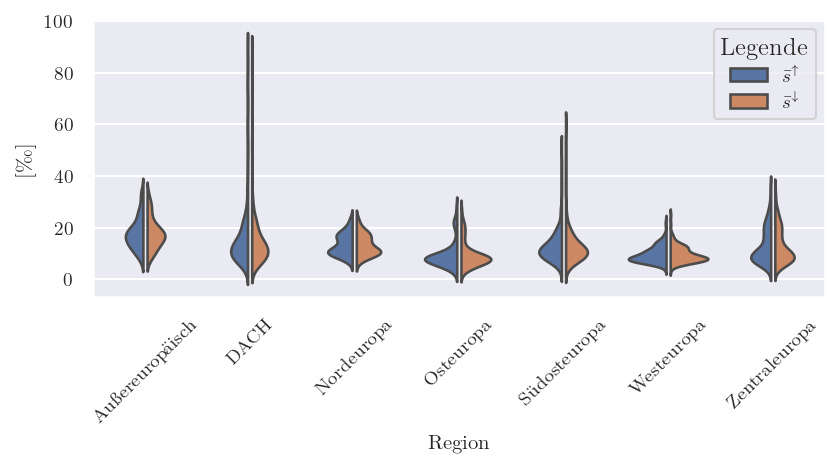

In [13]:
fig, ax = plt.subplots(1,1, figsize=(6.3,2.4))
sns.violinplot(data= df_height,
               x='region',
               y='value',
               hue= 'variable',
               split= True,
               ax= ax,
               inner= None,
               gap= 0.1,
               #cut= 0,
               #native_scale=True,
               order=order)
plt.legend(title='Legende')
plt.xlabel('Region')
plt.ylabel(r'[\textperthousand]')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

/tmp/ipykernel_33617/1925807314.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


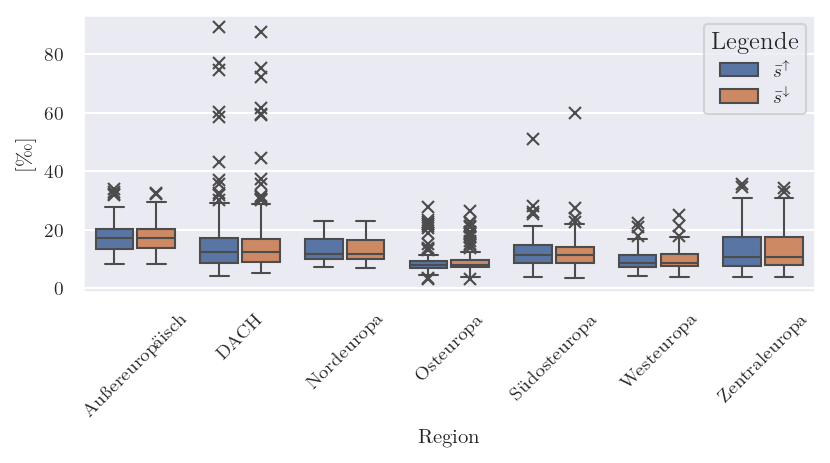

In [14]:
fig, ax = plt.subplots(1,1, figsize=(6.3,2.4))
sns.boxplot(data= df_height,
               x='region',
               y='value',
               hue= 'variable',
               #split= True,
               ax= ax,
               #inner= None,
               gap= 0.1,
               #cut= 0,
               #native_scale=True,
               order=order,
            flierprops={"marker": "x"})
plt.legend(title='Legende')
plt.xlabel('Region')
plt.ylabel(r'[\textperthousand]')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.savefig(RESULTS_DIR/'Verteilungen'/'heights_boxplot.png', dpi=600, bbox_inches='tight')

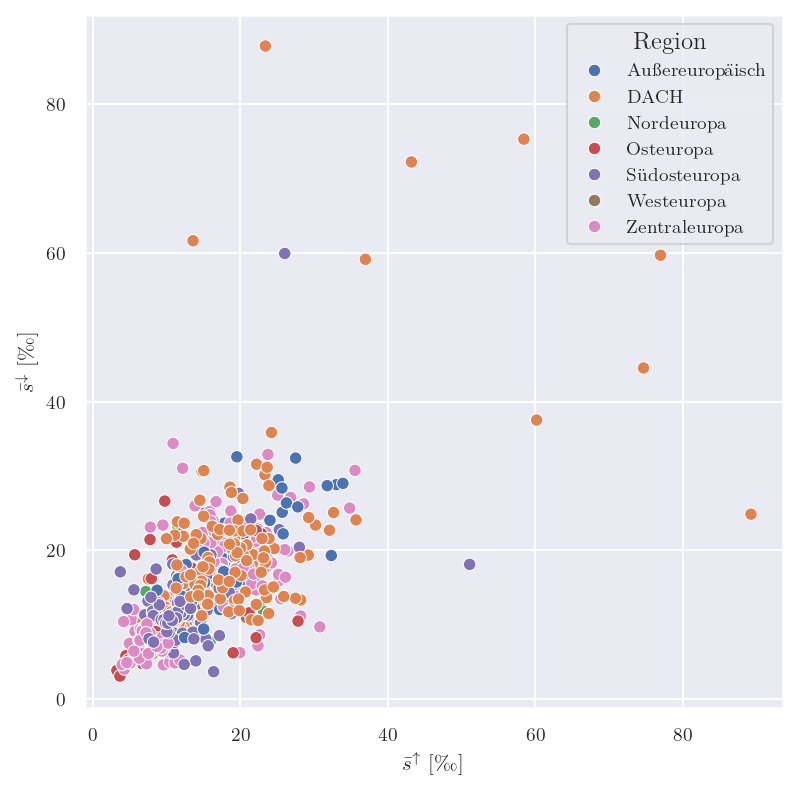

In [55]:
x_ax, y_ax = 'height_up', 'height_down'

fig, ax = plt.subplots(1,1,figsize=(6,6))
sns.scatterplot(data, x=x_ax, y=y_ax, hue='region', hue_order=order, ax=ax, marker='o')
plt.xlabel(da.COLUMN_NAMES_TEX[x_ax])
plt.ylabel(da.COLUMN_NAMES_TEX[y_ax])
plt.legend(title='Region')
plt.savefig(RESULTS_DIR/'Verteilungen'/'heights_scatterplot.pdf', dpi=600, bbox_inches='tight')

### Verteilung der Spurweiten auf die Regionen

In [15]:
df_draw=df_cities_grouped.groupby(by=['region','gauge'],observed=False).aggregate(func={'Stadt':'count'})
result = df_draw.unstack('region')
result=result.droplevel(0, axis=1)

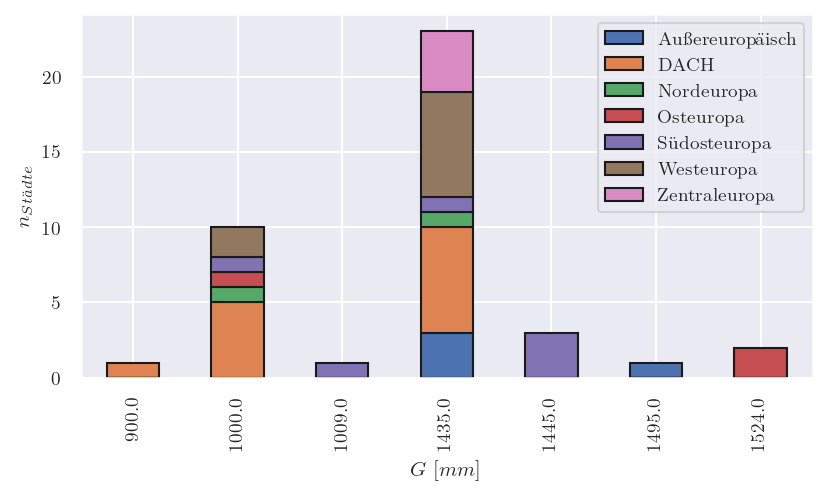

In [16]:
#g=sns.catplot(data=df_draw, x='gauge', y='Stadt', hue='region', kind='bar', hue_order=order)
#fig, ax = plt.subplots(1,1,figsize=(6.3,4.7))
g=result.plot(kind='bar', stacked=True, edgecolor='k')
plt.legend(order)
plt.xlabel(da.COLUMN_NAMES_TEX['gauge'])
plt.ylabel(r'$n_{St\ddot{a}dte}$')
plt.savefig(RESULTS_DIR / 'Spurweiten_diagramm.png', dpi=600, bbox_inches='tight')

In [17]:
data[data['gauge']==1495]['Stadt']

819    Toronto
820    Toronto
821    Toronto
822    Toronto
823    Toronto
824    Toronto
825    Toronto
826    Toronto
827    Toronto
828    Toronto
829    Toronto
830    Toronto
Name: Stadt, dtype: object

### Lineare Regression

In [18]:
data[data['Stadt']=='Portland']

,line_name,line_number,from,to,distance,curvature,height_up,height_down,gauge,gtfs_first_stop_name,...,OSM-Name,GTFS-Provider,Buffer_Width,H0_strasse,H0_tram,phi_street,phi_tram,region,rho_b,geometry
563,Streetcar A: Clockwise,A,Northwest Lovejoy & 9th,Northwest Lovejoy & 9th,9.896795,227.250354,26.271132,26.372175,1435.0,NW 9th & Lovejoy,...,"Portland, OR, USA",fahrplan_Portland,83.226187,2.63793,3.390858,0.67544,0.167658,Außereuropäisch,26.212175,"LINESTRING (-122.68052 45.53008, -122.68048 45..."
564,Streetcar B: Counter-clockwise,B,Northwest 11th & Marshall,Northwest 11th & Marshall,10.192494,258.777770,24.037295,24.037295,1435.0,NW 11th & Marshall,...,"Portland, OR, USA",fahrplan_Portland,83.226187,2.63793,3.390858,0.67544,0.167658,Außereuropäisch,25.500832,"LINESTRING (-122.68244 45.53091, -122.68244 45..."
565,Streetcar NS: Northwest 23rd & Marshall => Sou...,NS,Northwest 23rd & Marshall,South Lowell & Bond,6.239499,239.162750,25.162278,29.489549,1435.0,NW 23rd & Marshall,...,"Portland, OR, USA",fahrplan_Portland,83.226187,2.63793,3.390858,0.67544,0.167658,Außereuropäisch,32.992065,"LINESTRING (-122.69867 45.53062, -122.69867 45..."
566,Streetcar NS: South Lowell & Bond => Northwest...,NS,South Lowell & Bond,Northwest 23rd & Marshall,6.414926,250.356223,33.047925,28.838991,1435.0,S Lowell & Bond,...,"Portland, OR, USA",fahrplan_Portland,83.226187,2.63793,3.390858,0.67544,0.167658,Außereuropäisch,33.657113,"LINESTRING (-122.67138 45.49392, -122.6713 45...."


Text(65.02760504246766, 0.5, '$\\bar V$ $[km/h]$')

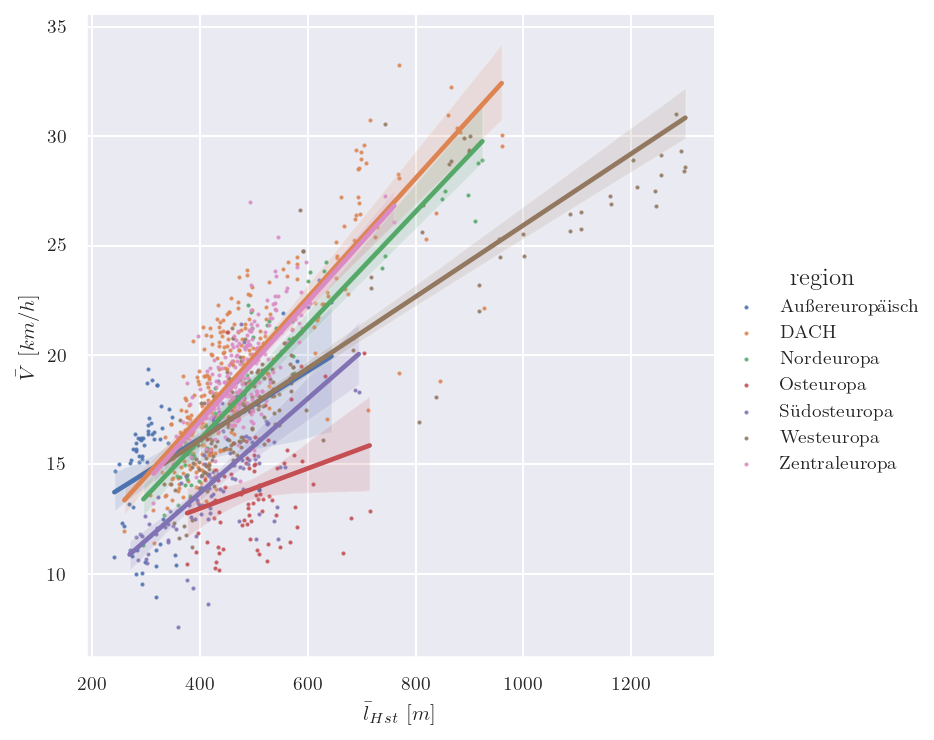

In [19]:
g=sns.lmplot(data=data.dropna(axis='index'), y='trip_speed', x='avg_dist', hue='region', hue_order=order, order=1, scatter_kws={'s':1})
#g._legend.set_title(title='Region')
plt.xlabel(da.COLUMN_NAMES_TEX['avg_dist'])
plt.ylabel(da.COLUMN_NAMES_TEX['trip_speed'])
#plt.xlim(0,1400)
#plt.ylim(0,35)


## Beschreibende Statistik Parameter

In [20]:
cols=list(da.COLUMN_NAMES_DE.keys())
data[data.columns.intersection(cols)].describe()

,curvature,height_up,height_down,gauge,trip_speed,avg_dist,Buffer_Width,rho_b
count,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000
mean,146.223275,12.964650,13.014234,1368.415020,17.972222,485.591669,88.141037,22.377509
std,66.533436,7.340290,7.481493,170.617462,4.130975,149.567188,16.418299,7.708268
min,15.326808,3.291302,3.087368,900.000000,7.547809,242.124134,59.754241,5.967341
25%,96.756185,8.192964,8.193079,1435.000000,15.212981,407.965972,80.346044,16.266507
50%,136.265705,11.189700,11.176352,1435.000000,17.659457,462.277778,84.962242,21.578924
75%,181.764309,15.681806,15.807120,1435.000000,20.165640,515.339624,93.533469,27.828860
max,483.888051,89.217482,87.834918,1524.000000,33.255673,1299.915768,129.472409,43.795378


In [21]:
weighted_average(data, 'trip_speed', 'number_trips')

np.float64(17.65123628126602)

In [22]:
df_region=data.groupby(by='region').aggregate(func=agg_func)
df_region['trip_speed']=data.groupby(by='region').apply(weighted_average, 'trip_speed', 'number_trips')
df_region.sort_values(by='trip_speed', ascending=False)
df_region['curvature']['mean'].max()

/tmp/ipykernel_33617/1532576771.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_region['trip_speed']=data.groupby(by='region').apply(weighted_average, 'trip_speed', 'number_trips')


np.float64(207.2270922346314)

/tmp/ipykernel_33617/2923588337.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(axs.get_xticklabels(), rotation=45)


[Text(0, 0, 'Außereuropäisch'),
 Text(1, 0, 'DACH'),
 Text(2, 0, 'Nordeuropa'),
 Text(3, 0, 'Osteuropa'),
 Text(4, 0, 'Südosteuropa'),
 Text(5, 0, 'Westeuropa'),
 Text(6, 0, 'Zentraleuropa')]

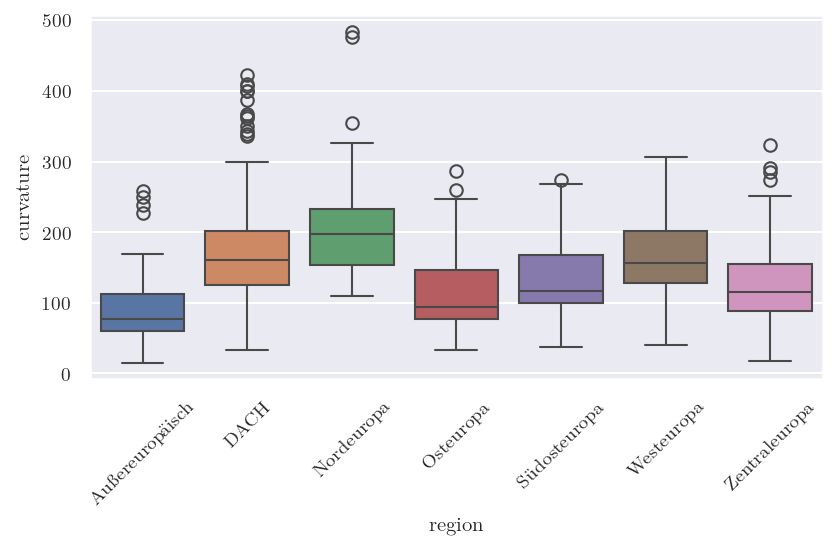

In [23]:
axs=sns.boxplot(data, y='curvature', hue='region', x='region', hue_order=order, order=order)
axs.set_xticklabels(axs.get_xticklabels(), rotation=45)

In [24]:
data.sort_values('height_up', ascending=False)

,line_name,line_number,from,to,distance,curvature,height_up,height_down,gauge,gtfs_first_stop_name,...,OSM-Name,GTFS-Provider,Buffer_Width,H0_strasse,H0_tram,phi_street,phi_tram,region,rho_b,geometry
431,50: Hauptplatz - Pöstlingberg,50,Hauptplatz,Pöstlingberg,4.102335,387.353725,89.217482,24.863889,900.0,Linz/Donau Hauptplatz,...,"Linz, Austria",fahrplan_Linz,98.379516,3.544017,3.214863,0.035628,0.307377,DACH,15.813554,"LINESTRING (14.28611 48.30636, 14.28608 48.306..."
338,Tram STB: Innsbruck => Fulpmes,STB,Innsbruck Hauptbahnhof,Fulpmes Bahnhof,20.554806,400.533843,76.964968,59.694068,1000.0,Innsbruck Hauptbahnhof D,...,"Innsbruck, Austria",fahrplan_Innsbruck,92.892269,3.541290,3.346137,0.038064,0.204377,DACH,9.974726,"LINESTRING (11.40024 47.2637, 11.40021 47.2635..."
339,Tram STB: Innsbruck => Mutters,STB,Innsbruck Hauptbahnhof,Mutters Kreith,13.045359,407.271250,74.662570,44.536913,1000.0,Innsbruck Hauptbahnhof D,...,"Innsbruck, Austria",fahrplan_Innsbruck,92.892269,3.541290,3.346137,0.038064,0.204377,DACH,13.793168,"LINESTRING (11.40024 47.2637, 11.40021 47.2635..."
336,Tram 6: Innsbruck Mühlauer Brücke => Igls,6,Innsbruck Mühlauer Brücke,Igls Bahnhof,12.845299,364.705590,60.177657,37.523455,1000.0,Innsbruck Mühlauer Brücke,...,"Innsbruck, Austria",fahrplan_Innsbruck,92.892269,3.541290,3.346137,0.038064,0.204377,DACH,15.531680,"LINESTRING (11.40392 47.27826, 11.4038 47.2777..."
337,Tram STB: Fulpmes => Innsbruck,STB,Fulpmes Bahnhof,Innsbruck Hauptbahnhof,21.045843,410.029418,58.443845,75.311784,1000.0,Fulpmes Bahnhof,...,"Innsbruck, Austria",fahrplan_Innsbruck,92.892269,3.541290,3.346137,0.038064,0.204377,DACH,10.693810,"LINESTRING (11.35242 47.15562, 11.35255 47.155..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,Tram T46: Katowice Plac Miarki → Zawodzie Zaje...,T46,Katowice Plac Miarki,Zawodzie Zajezdnia,4.032654,149.565203,4.215586,10.414978,1435.0,Katowice Plac Miarki,...,"Katowice, Poland",fahrplan_Katowice,80.600791,3.527529,3.462150,0.050308,0.107409,Zentraleuropa,26.081838,"LINESTRING (19.01773 50.25441, 19.01775 50.254..."
883,Tram 31: PKP Służewiec => Metro Wierzbno,31,PKP Służewiec,Metro Wierzbno,3.235931,167.888412,4.017392,4.635452,1435.0,PKP Służewiec,...,"Warsaw, Poland",fahrplan_Warschau,91.025085,3.548341,3.515334,0.031760,0.061094,Zentraleuropa,15.373932,"LINESTRING (20.98879 52.18184, 20.98875 52.181..."
789,Трамвай 5: кв. Княжево → Съдебна палата,5,кв. Княжево,Съдебна палата,7.714159,94.297318,3.759321,17.111393,1009.0,КВ. КНЯЖЕВО,...,"Sofia, Bulgaria",fahrplan_Sofia,94.072147,3.562309,3.463502,0.019210,0.106246,Südosteuropa,21.821371,"LINESTRING (23.24191 42.65891, 23.24191 42.658..."
758,Трамвай № 62: станция метро «Купчино» => Малая...,62,станция метро «Купчино»,Малая Балканская улица,3.239005,120.134082,3.704841,3.087368,1524.0,"Конечная Станция ""ст. Метро ""Купчино""",...,"Saint Petersburg, Russia",fahrplan_SanktPetersburg,129.472409,3.564783,3.536324,0.016979,0.042492,Osteuropa,13.610051,"LINESTRING (30.37803 59.83137, 30.3783 59.8311..."


## Get OSMNx Data (Entropy and Oritentations)

In [25]:
cities_df = pd.read_csv('./data/cities.csv', delimiter=';')
cities_dict=cities_df[['OSM-Name', 'RailModes']].set_index('OSM-Name').to_dict()['RailModes']

list_to_get=list(data['Stadt'].unique())
list_to_get

['Amsterdam',
 'Antwerpen',
 'Berlin',
 'Bordeaux',
 'Brandenburg a. d. Havel',
 'Brüssel',
 'Budapest',
 'Bukarest',
 'Den Haag',
 'Freiburg',
 'Gent',
 'Göteborg',
 'Graz',
 'Helsinki',
 'Innsbruck',
 'Katowice',
 'Köln',
 'Linz',
 'Lviv',
 'Lyon',
 'Mailand',
 'Manchester',
 'Melbourne',
 'München',
 'Portland',
 'Potsdam',
 'Prag',
 'Riga',
 'Rom',
 'Rotterdam',
 'San Francisco',
 'Sankt Petersburg',
 'Sofia',
 'Stuttgart',
 'Turin',
 'Toronto',
 'Ulm',
 'Warschau',
 'Wien',
 'Zagreb',
 'Zürich']

To calculate the Entropy data, use Entropy.py in the Main Directory.
The List to query in Entropy.py is the above returned List.

In [26]:
orientations=pd.read_csv(RESULTS_DIR / 'Orientations.csv')
#orientations.rename(axis='columns', inplace=True, mapper={0:'Stadt', 1:'H0_strasse', 2:'H0_tram'})
orientations['deltaphi']=abs(orientations['phi_street']-orientations['phi_tram'])
orientations.sort_values(by='deltaphi', ascending=False)

,Stadt,H0_strasse,H0_tram,phi_street,phi_tram,deltaphi
24,Portland,2.637930,3.390858,0.675440,0.167658,0.507783
17,Linz,3.544017,3.214863,0.035628,0.307377,0.271748
14,Innsbruck,3.541290,3.346137,0.038064,0.204377,0.166313
36,Ulm,3.556633,3.372336,0.024319,0.182966,0.158646
21,Manchester,3.565282,3.384425,0.016529,0.172990,0.156461
8,Den Haag,3.295176,3.476335,0.245209,0.095171,0.150038
5,Brüssel,3.542412,3.370044,0.037062,0.184850,0.147788
19,Lyon,3.501167,3.339738,0.073546,0.209563,0.136017
30,San Francisco,3.256287,3.416363,0.275645,0.146346,0.129299
34,Toronto,2.963162,3.136868,0.484905,0.365193,0.119711


## Feld für schnelle Abfragem

In [27]:
data[data.Buffer_Width == data.Buffer_Width.min()]

,line_name,line_number,from,to,distance,curvature,height_up,height_down,gauge,gtfs_first_stop_name,...,OSM-Name,GTFS-Provider,Buffer_Width,H0_strasse,H0_tram,phi_street,phi_tram,region,rho_b,geometry
473,Manchester Metrolink: ECL OUT,ECL,Cornbrook Junction,Eccles,3.827945,168.059561,10.449470,8.098340,1435.0,Cornbrook (Manchester Metrolink),...,"Manchester, UK",fahrplan_Manchester,59.754241,3.565282,3.384425,0.016529,0.17299,Westeuropa,18.464572,"LINESTRING (-2.29776 53.47203, -2.29769 53.472..."
474,Metrolink: Altrincham => Bury via Shudehill,Altrincham – Bury,Altrincham,Bury,30.105891,78.809294,11.260255,9.400154,1435.0,Altrincham (Manchester Metrolink),...,"Manchester, UK",fahrplan_Manchester,59.754241,3.565282,3.384425,0.016529,0.17299,Westeuropa,8.861903,"LINESTRING (-2.3475 53.3873, -2.34724 53.38777..."
475,Metrolink: Altrincham => Piccadilly,Piccadilly - Altrincham,Altrincham,Piccadilly,14.132465,86.282069,8.774124,7.925015,1435.0,Altrincham (Manchester Metrolink),...,"Manchester, UK",fahrplan_Manchester,59.754241,3.565282,3.384425,0.016529,0.17299,Westeuropa,11.103526,"LINESTRING (-2.3475 53.3873, -2.34724 53.38777..."
476,Metrolink: Bury => Altrincham via Shudehill,Altrincham – Bury,Bury,Altrincham,30.090048,73.266262,9.604504,11.465585,1435.0,Bury (Manchester Metrolink),...,"Manchester, UK",fahrplan_Manchester,59.754241,3.565282,3.384425,0.016529,0.17299,Westeuropa,8.856939,"LINESTRING (-2.29743 53.59059, -2.298 53.58971..."
477,Metrolink: Bury => Piccadilly,Bury - Manchester Piccadilly,Bury,Piccadilly,17.404127,105.446368,11.778815,14.306951,1435.0,Bury (Manchester Metrolink),...,"Manchester, UK",fahrplan_Manchester,59.754241,3.565282,3.384425,0.016529,0.17299,Westeuropa,9.979608,"LINESTRING (-2.29743 53.59059, -2.298 53.58971..."
478,Metrolink: Deansgate-Castlefield => Manchester...,Manchester Airport - Manchester Victoria,Deansgate-Castlefield,Manchester Airport,20.009098,131.987132,8.696044,6.846885,1435.0,Deansgate-Castlefield (Manchester Metrolink),...,"Manchester, UK",fahrplan_Manchester,59.754241,3.565282,3.384425,0.016529,0.17299,Westeuropa,7.373576,"LINESTRING (-2.25031 53.47474, -2.25074 53.474..."
479,Metrolink: East Didsbury => Rochdale Town Cent...,Rochdale - East Didsbury,East Didsbury,Rochdale Town Centre,37.184854,96.256012,11.536955,9.304864,1435.0,East Didsbury (Manchester Metrolink),...,"Manchester, UK",fahrplan_Manchester,59.754241,3.565282,3.384425,0.016529,0.17299,Westeuropa,12.313880,"LINESTRING (-2.21722 53.4121, -2.21795 53.4123..."
480,Metrolink: East Didsbury => Shaw & Crompton vi...,Shaw and Crompton - East Didsbury,East Didsbury,Shaw and Crompton,28.780741,93.794874,12.960055,8.304164,1435.0,East Didsbury (Manchester Metrolink),...,"Manchester, UK",fahrplan_Manchester,59.754241,3.565282,3.384425,0.016529,0.17299,Westeuropa,13.128620,"LINESTRING (-2.21722 53.4121, -2.21795 53.4123..."
481,Metrolink: Manchester Airport => Deansgate-Cas...,Manchester Airport - Manchester Victoria,Manchester Airport,Deansgate-Castlefield,20.028911,135.165135,6.690329,8.537658,1435.0,Manchester Airport (Manchester Metrolink),...,"Manchester, UK",fahrplan_Manchester,59.754241,3.565282,3.384425,0.016529,0.17299,Westeuropa,7.337439,"LINESTRING (-2.27233 53.36537, -2.27143 53.365..."
482,Metrolink: Manchester Airport => Victoria via ...,Manchester Airport - Manchester Victoria,Manchester Airport,Victoria,22.043048,162.448379,8.301937,9.662910,1435.0,Manchester Airport (Manchester Metrolink),...,"Manchester, UK",fahrplan_Manchester,59.754241,3.565282,3.384425,0.016529,0.17299,Westeuropa,10.983693,"LINESTRING (-2.27233 53.36537, -2.27143 53.365..."


## Kombinationen aus Parametern

In [28]:
combined_parameters=[['curvature', 'height_up', 'height_down'],
                     ['curvature', 'trip_speed'],
                     ['curvature', 'rho_b'],
                     ['avg_dist', 'rho_b'],
                     ['trip_speed', 'avg_dist']]

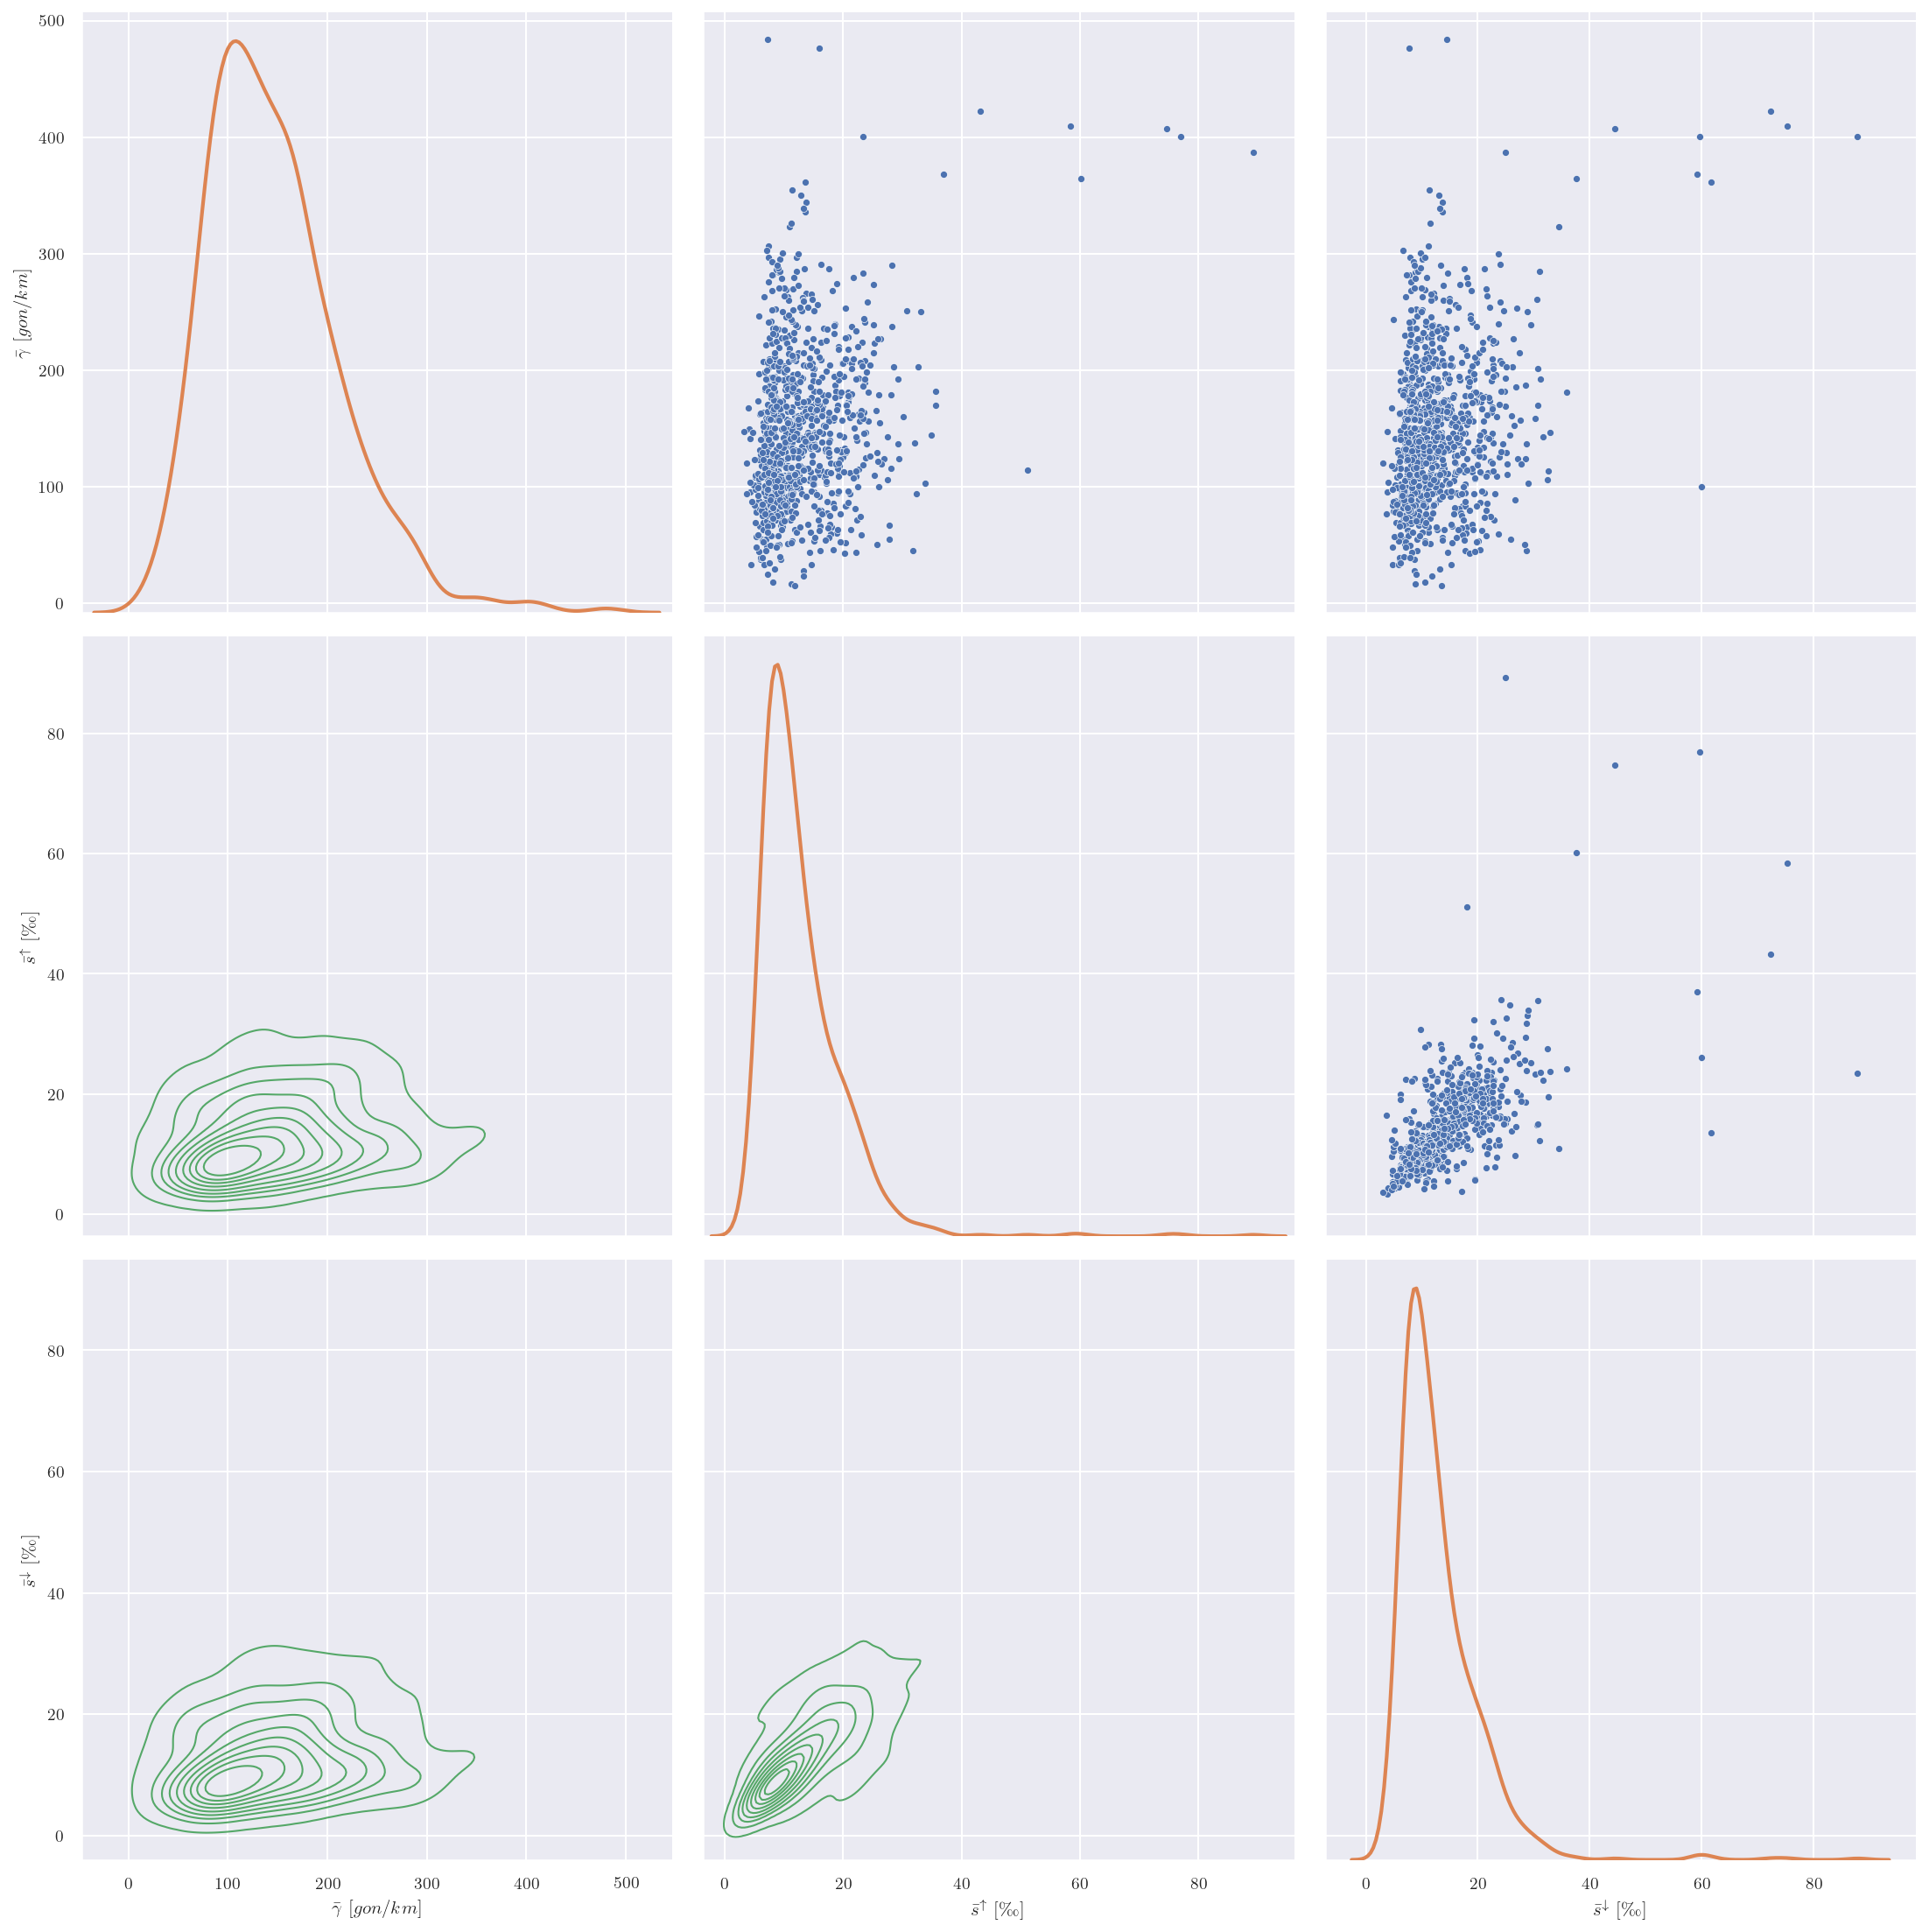

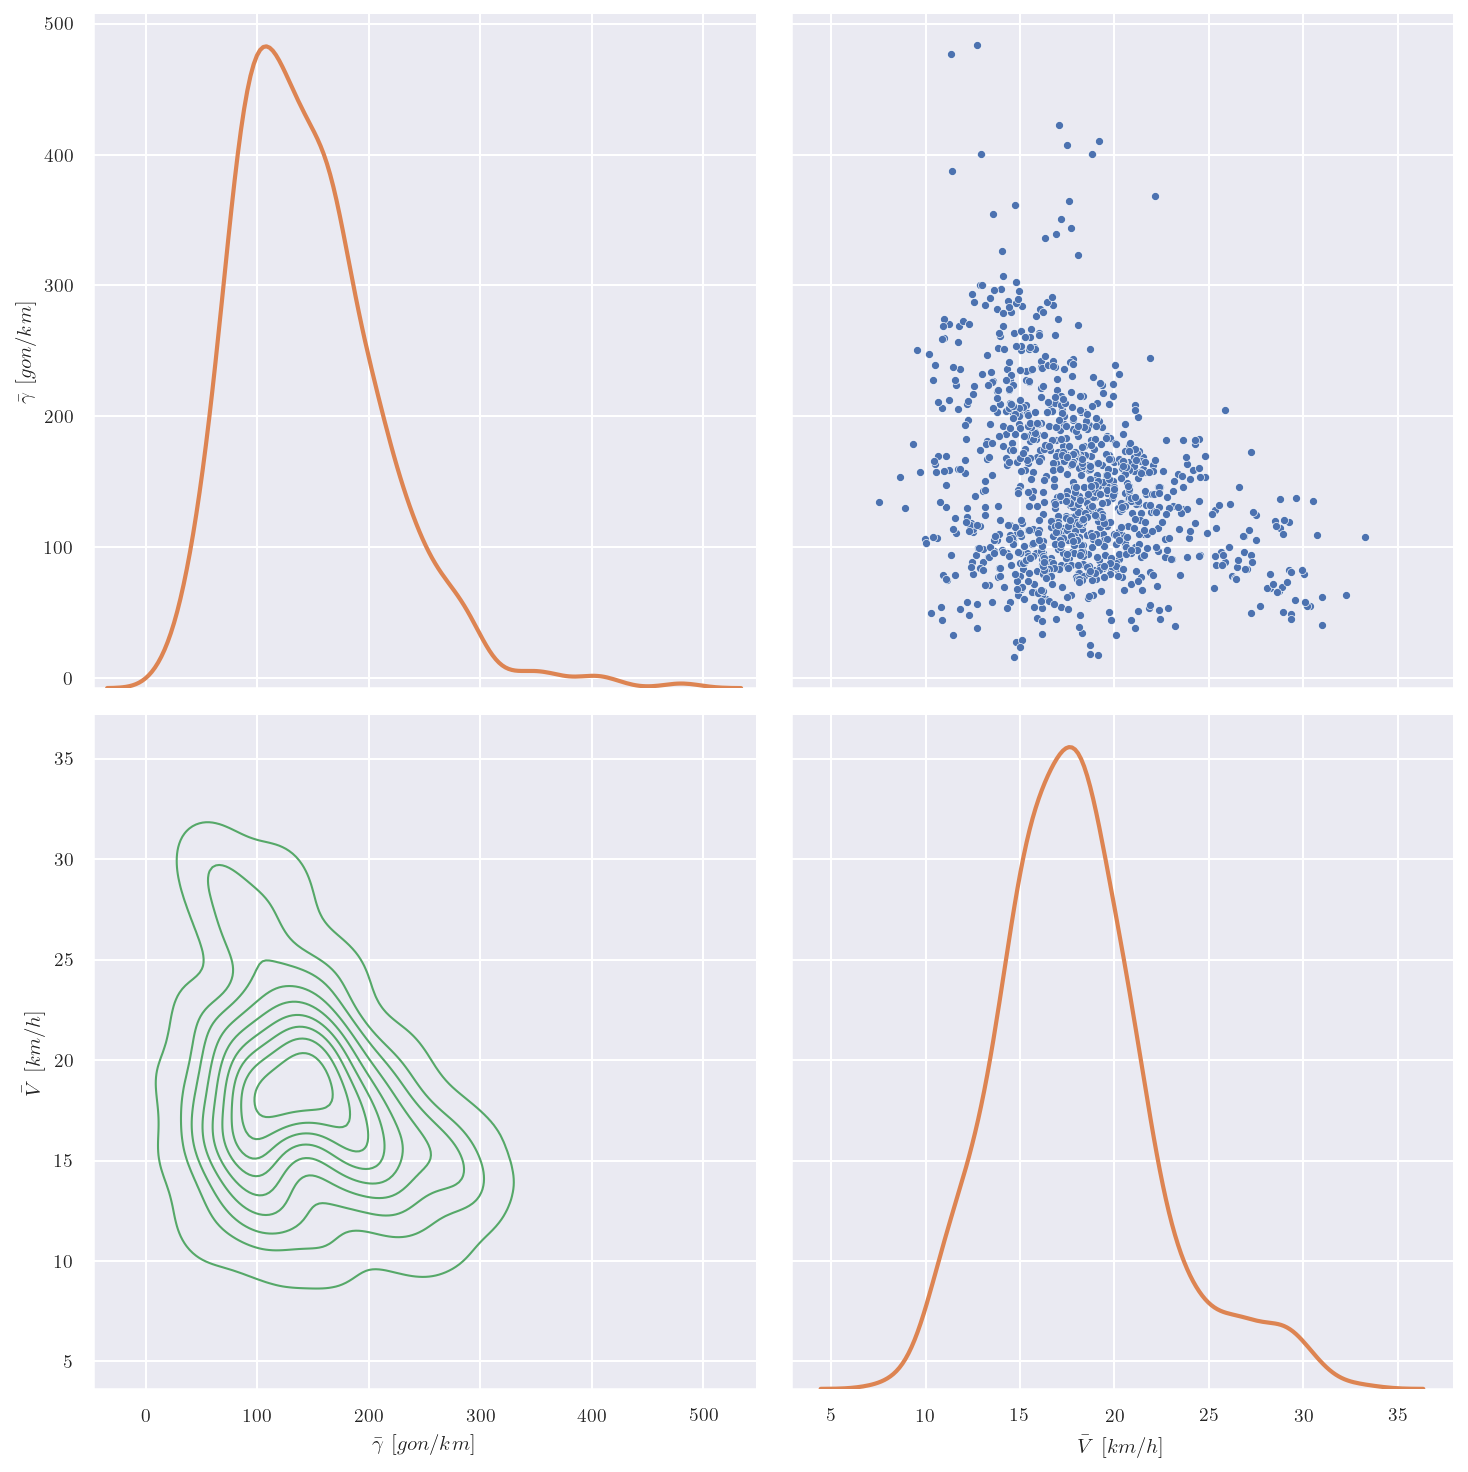

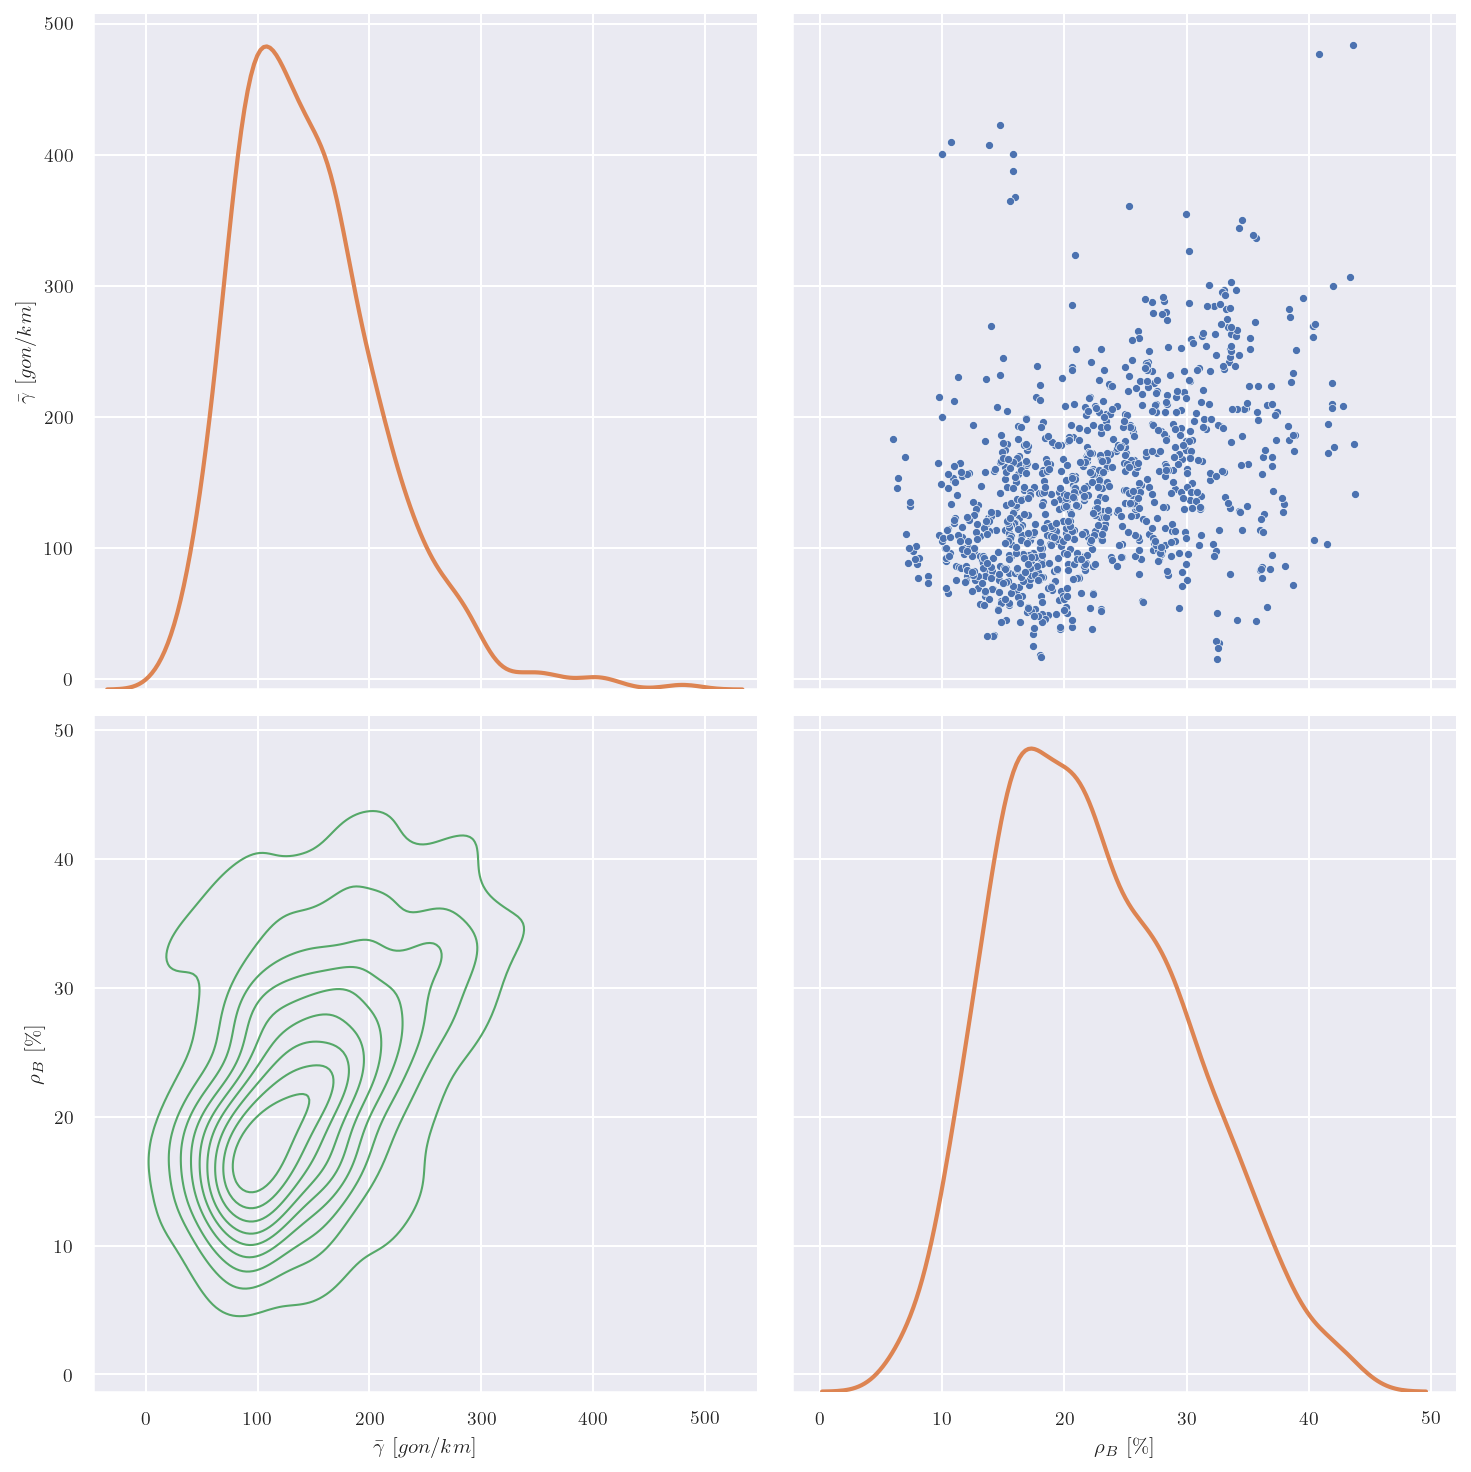

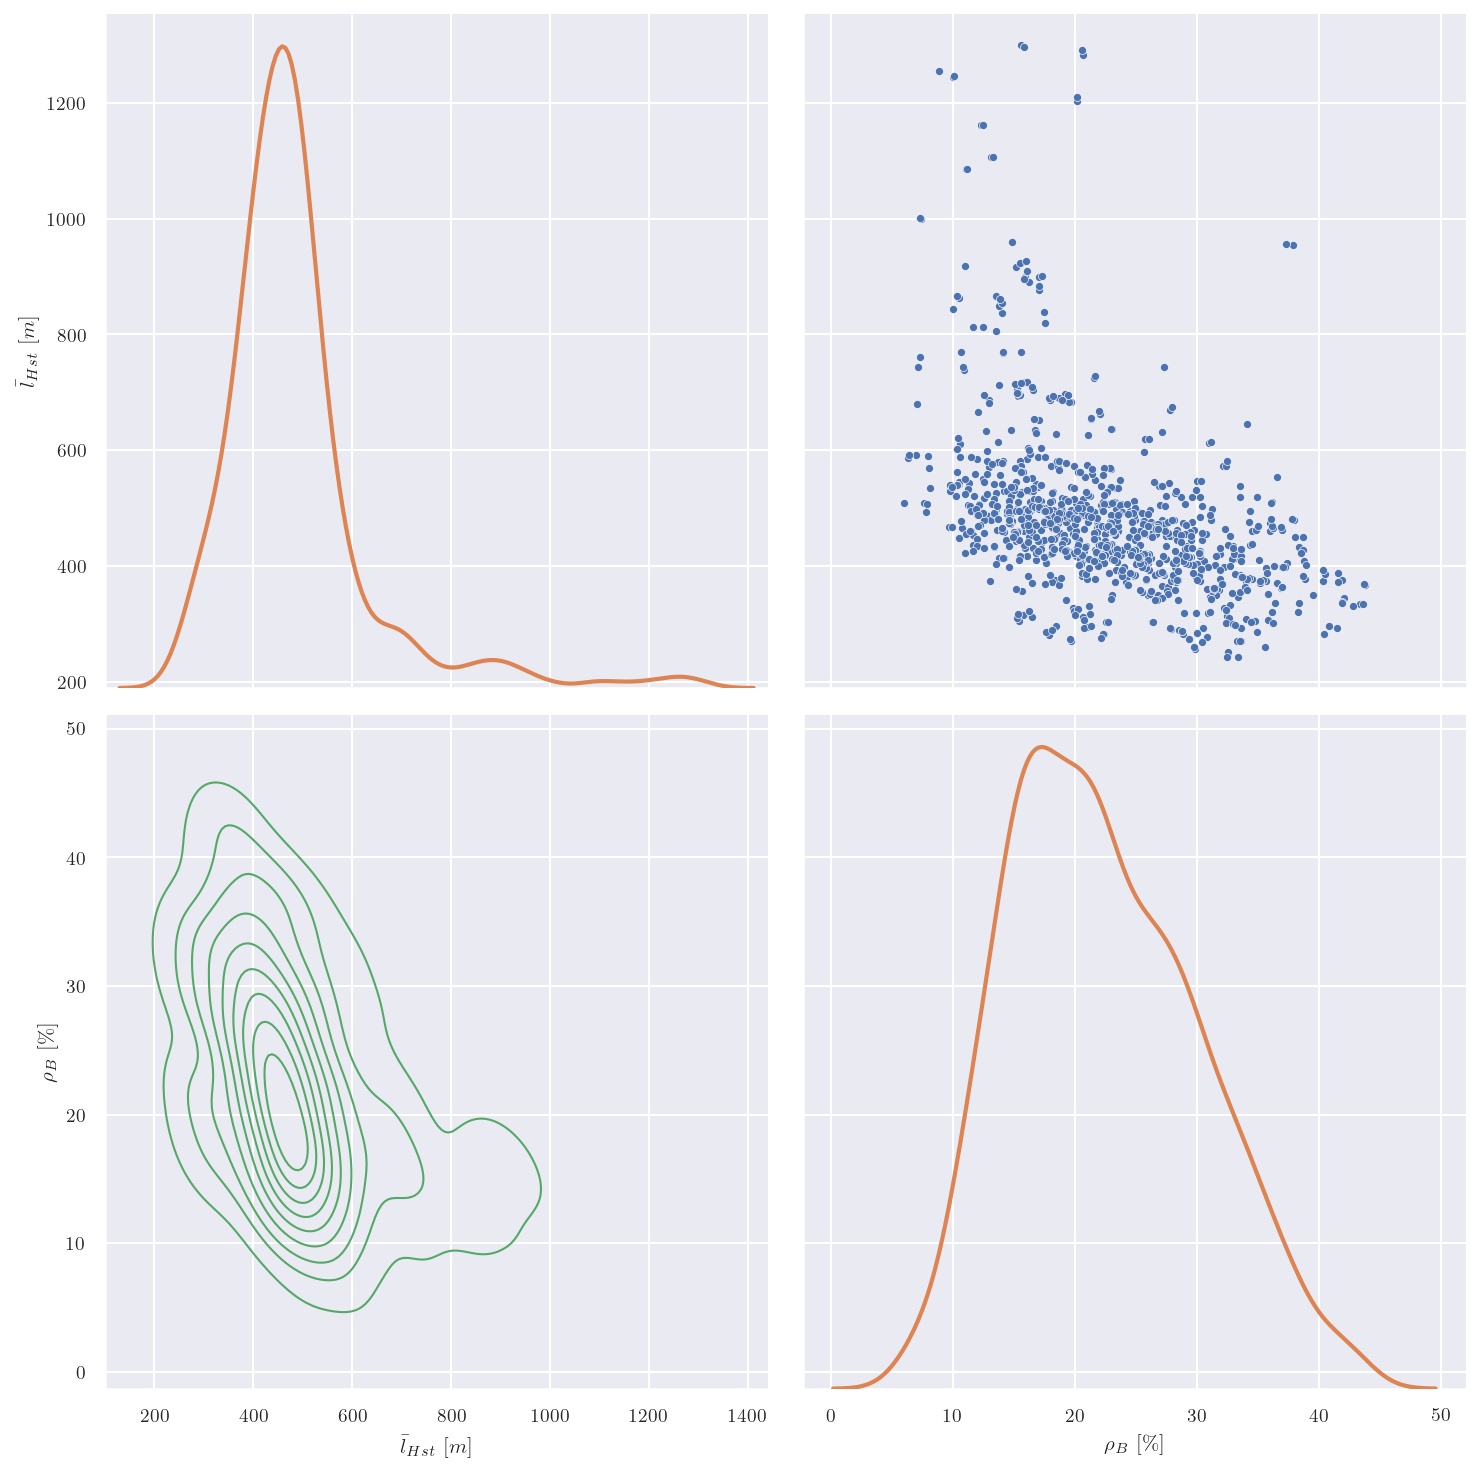

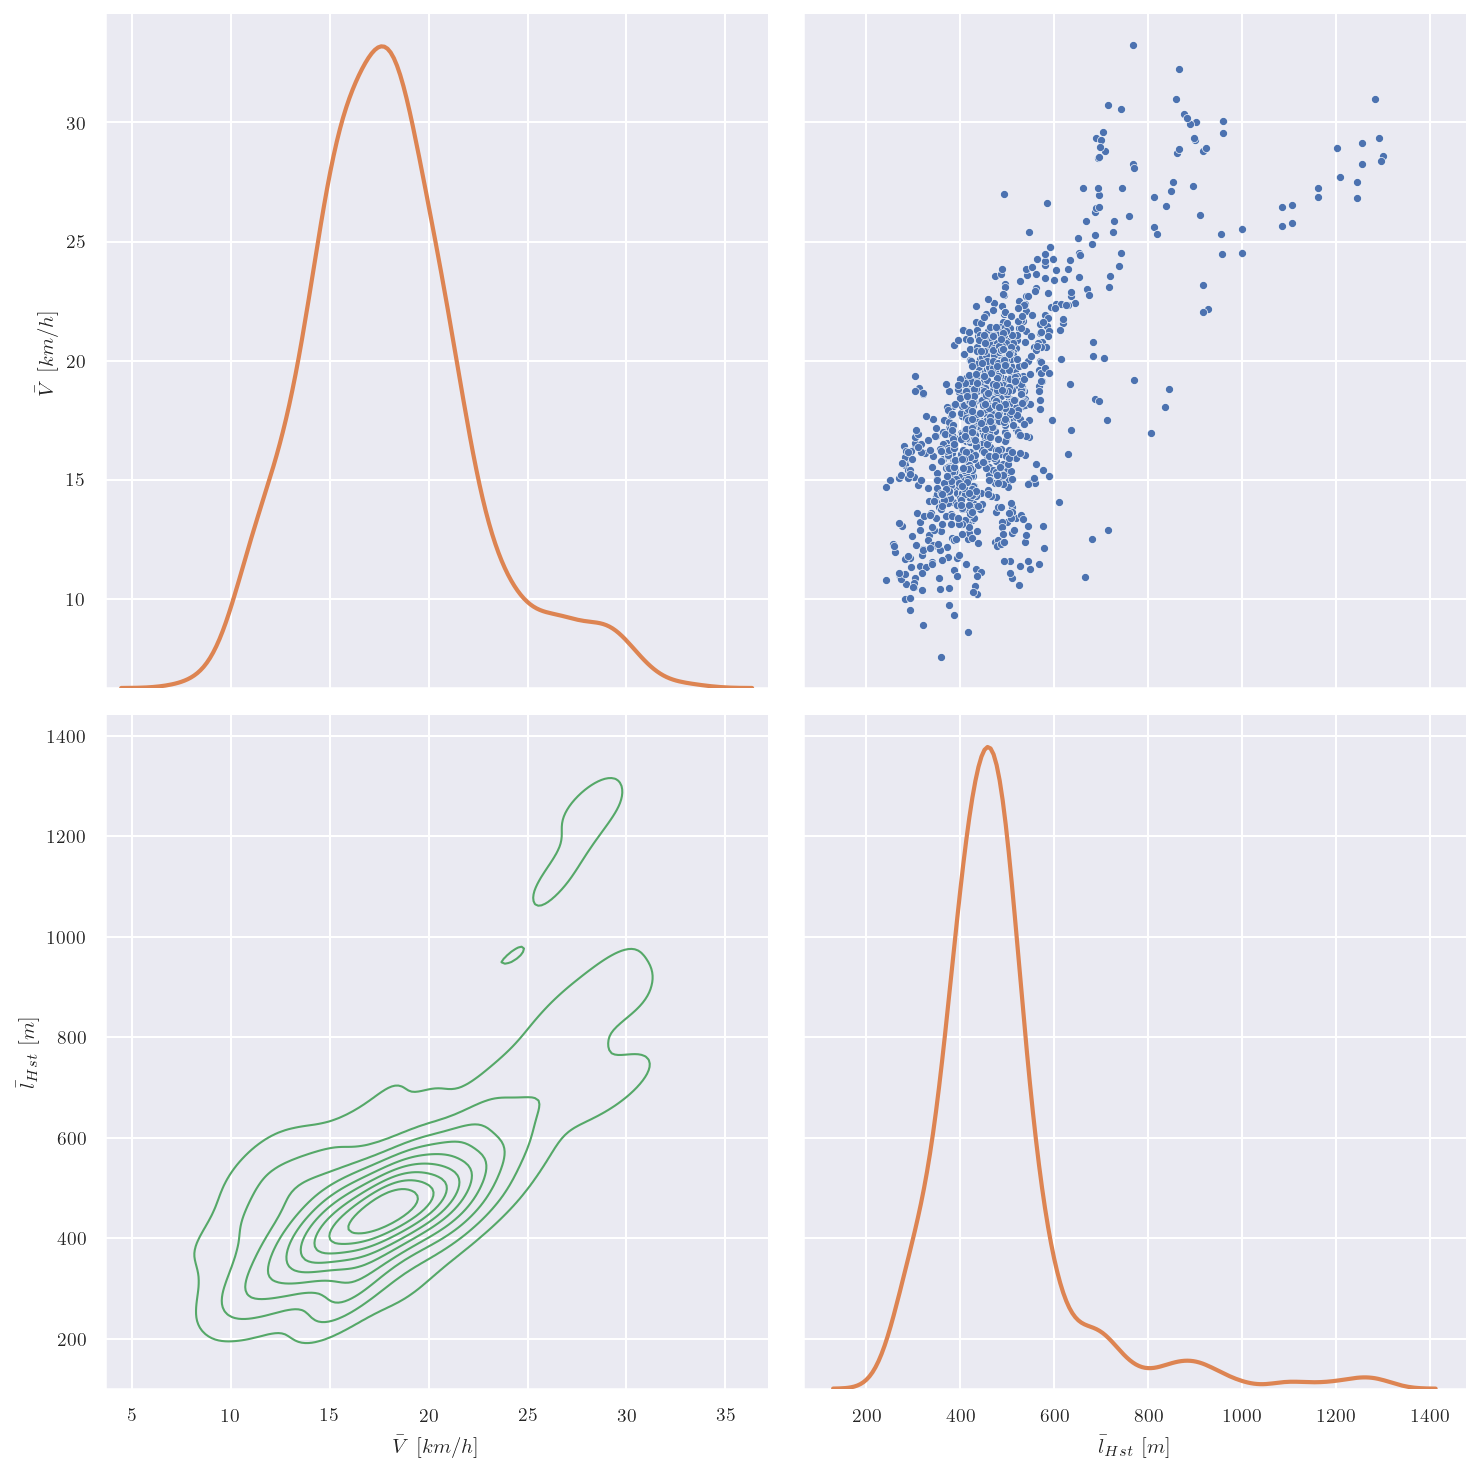

In [29]:
for combination in combined_parameters:
    data_plot=data[combination].rename(columns=da.COLUMN_NAMES_TEX)
    g = sns.PairGrid(data=data_plot, diag_sharey=False, height=5, aspect=1)
    g.map_upper(sns.scatterplot, s=15, color='C0')
    g.map_diag(sns.kdeplot, lw=2, color='C1')
    g.map_lower(sns.kdeplot, linewidths=1, color='C2')

    filename='pairplot_'+'_'.join(combination)+'.png'
    g.figure.savefig(RESULTS_DIR / 'Kombinationen'/ filename, dpi=600, bbox_inches='tight')

In [30]:
combined_parameters=[['curvature', 'height_up', 'height_down'],
                     ['curvature', 'trip_speed'],
                     ['curvature', 'rho_b'],
                     ['rho_b', 'avg_dist'],
                     ['trip_speed', 'avg_dist']]

for combination in combined_parameters:
    fig,axs=plt.subplots(1,1, figsize=(6.3,6.3))
    da.add_subplot(data,
                   x=(combination[0],da.COLUMN_NAMES_TEX[combination[0]]),
                   y=(combination[1],da.COLUMN_NAMES_TEX[combination[1]]),
                   axs=axs,
                   subaxis=0)

    filename='scatterplot_'+'_'.join(combination)+'.png'

    plt.savefig(fname=RESULTS_DIR / 'Kombinationen' / filename, dpi=300, bbox_inches='tight')
    plt.close()

/home/flof/Documents/Diplomarbeit/osm-horizontal-curvature/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/flof/Documents/Diplomarbeit/osm-horizontal-curvature/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/flof/Documents/Diplomarbeit/osm-horizontal-curvature/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/flof/Documents/Diplomarbeit/osm-horizontal-curvature/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/flof/Docum

/home/flof/Documents/Diplomarbeit/osm-horizontal-curvature/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


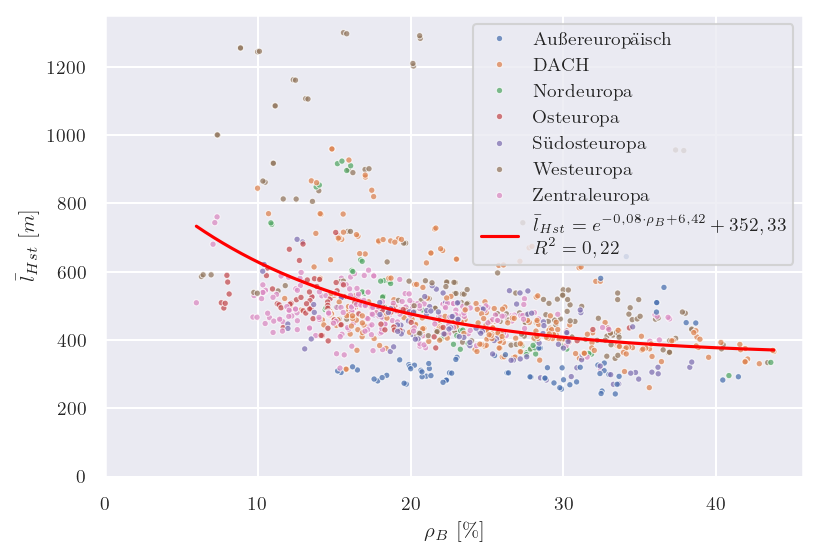

In [31]:
#data['dist_log'] = np.log(data['avg_dist'])

x_ax='rho_b'
y_ax='avg_dist'

data_unabh = data[[x_ax]]
x_between = np.linspace(data_unabh.min(), data_unabh.max(), 1000)

def function(x,b, c, d):
    #y=a*x + b
    #y=b*np.log(x+c)+d
    y=np.exp(-x*b+c)+d
    return y

# fit = np.polyfit(np.log(data['avg_dist']), data['rho_b'], 1)
# fx = [fit[0]*np.log(x) + fit[1] for x in x_between]

popt, pcov = opt.curve_fit(function, data[x_ax], data[y_ax], maxfev=5000)
popt = np.round(popt, 2)

residuals = data[y_ax]- function(data[x_ax], *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((data[y_ax]-np.mean(data[y_ax]))**2)
r_squared = 1 - (ss_res / ss_tot)



intercept_err = np.sqrt(pcov[0][0])
slope_err = np.sqrt(pcov[1][1])

fx = [function(x, *popt) for x in x_between]

fig, axs = plt.subplots(1,1, figsize=(6,4))

sns.scatterplot(data=data, x=x_ax, y=y_ax, ax=axs, alpha=0.75, hue='region', hue_order=order, marker='.')  # , marker='x', s=10, c="navy")
intercept_pre = '+' if popt[1] > 0 else ''
label_reg=(r"$\bar l_{{Hst}}=e^{{ -{0:.2f}\cdot \rho_B{4:}{1:.2f} }}+{2:.2f}$"+ '\n' +r"$R^2={3:.2f}$").format(*popt, r_squared, intercept_pre).replace('.', ',')
axs.plot(x_between[:, 0], fx, c="red", label=label_reg)
plt.legend()
plt.xlabel(da.COLUMN_NAMES_TEX[x_ax])
plt.ylabel(da.COLUMN_NAMES_TEX[y_ax])
plt.ylim(0)
plt.xlim(0)

filename='scatterplot_'+x_ax+'_'+y_ax+'.png'
plt.savefig(fname=RESULTS_DIR / 'Kombinationen' / filename, dpi=600, bbox_inches='tight')



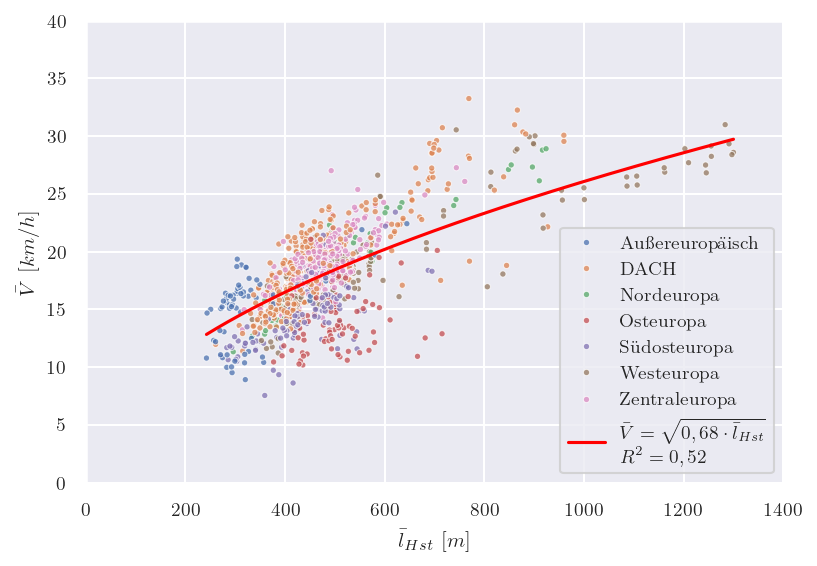

In [32]:
x_ax='avg_dist'
y_ax='trip_speed'

data_unabh = data[[x_ax]]
x_between = np.linspace(data_unabh.min(), data_unabh.max(), 1000)

def function(x, a):
    y=np.sqrt(a*x)
    #y=a*x+d
    #y=a*np.log(x)+d
    #y=np.exp(a*x+c)+d
    return y

# fit = np.polyfit(np.log(data['avg_dist']), data['rho_b'], 1)
# fx = [fit[0]*np.log(x) + fit[1] for x in x_between]

popt, pcov = opt.curve_fit(function, data[x_ax], data[y_ax], maxfev=5000)
popt = np.round(popt, 2)

residuals = data[y_ax]- function(data[x_ax], *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((data[y_ax]-np.mean(data[y_ax]))**2)
r_squared = 1 - (ss_res / ss_tot)



#intercept_err = np.sqrt(pcov[0][0])
#slope_err = np.sqrt(pcov[1][1])

fx = [function(x, *popt) for x in x_between]

fig, axs = plt.subplots(1,1, figsize=(6,4))

sns.scatterplot(data=data, x=x_ax, y=y_ax, ax=axs, alpha=0.75, hue='region', hue_order=order, marker='.')#, s=10, c="navy")
#intercept_pre = '+' if popt[1] > 0 else ''
label_reg=(r"$\bar V=\sqrt{{{0:.2f} \cdot \bar l_{{Hst}}}}$"+ '\n' +r"$R^2={1:.2f}$").format(*popt, r_squared).replace('.', ',')
axs.plot(x_between[:, 0], fx, c="red", label=label_reg)
plt.legend()
plt.xlabel(da.COLUMN_NAMES_TEX[x_ax])
plt.ylabel(da.COLUMN_NAMES_TEX[y_ax])
plt.xlim((0,1400))
plt.ylim((0,40))
#plt.xscale('log')
filename='scatterplot_'+x_ax+'_'+y_ax+'.pdf'
plt.savefig(fname=RESULTS_DIR / 'Kombinationen' / filename, dpi=300, bbox_inches='tight')

In [33]:
r_squared
#popt

np.float64(0.5170452524187744)

In [34]:
df_region

distance              number_trips   curvature              \
                      mean          sum          sum        mean         min   
region                                                                         
Außereuropäisch  13.029164   899.012283      47993.0   91.005681   15.326808   
DACH             11.093683  3283.730254     165128.0  168.631111   32.859143   
Nordeuropa       13.035715   651.785761      51416.0  207.227092  109.736756   
Osteuropa        10.618093   860.065493      13802.0  109.954104   32.751032   
Südosteuropa      9.385142  1051.135918      42406.0  137.280094   37.711134   
Westeuropa       12.413080  2110.223582     101038.0  164.263766   39.907599   
Zentraleuropa    12.647229  2959.451674      90624.0  124.854299   16.884854   

                               avg_dist      rho_b machine_readable  \
                        max        mean       mean            count   
region                                                                
Außereuropäisch  258.777770  327.367133  26.742472               69   
DACH             422.539982  477.890733  24.369677              296   
Nordeuropa       483.888051  515.427634  21.838952               50   
Osteuropa        287.087878  500.560961  15.981585               81   
Südosteuropa     274.586721  433.757998  23.936836              112   
Westeuropa       307.089667  588.789659  24.181444              170   
Zentraleuropa    323.427031  480.268471  18.842552              234   

                     Stadt ISO3166   gauge           region Buffer_Width  \
                     first   first   first            first         mean   
region                                                                     
Außereuropäisch  Melbourne      AU  1435.0  Außereuropäisch    84.525291   
DACH                Berlin      DE  1435.0             DACH    94.889159   
Nordeuropa        Göteborg      SE  1435.0       Nordeuropa    83.277330   
Osteuropa             Lviv      UA  1000.0        Osteuropa   121.865618   
Südosteuropa      Bukarest      RO  1435.0     Südosteuropa    81.690949   
Westeuropa       Amsterdam      NL  1435.0       Westeuropa    68.874595   
Zentraleuropa     Budapest      HU  1435.0    Zentraleuropa    87.120703   

                trip_speed  
                            
region                      
Außereuropäisch  15.447930  
DACH             17.356314  
Nordeuropa       19.300787  
Osteuropa        13.992055  
Südosteuropa     14.463452  
Westeuropa       19.072430  
Zentraleuropa    18.884027

<Axes: xlabel='rho_b', ylabel='trip_speed'>

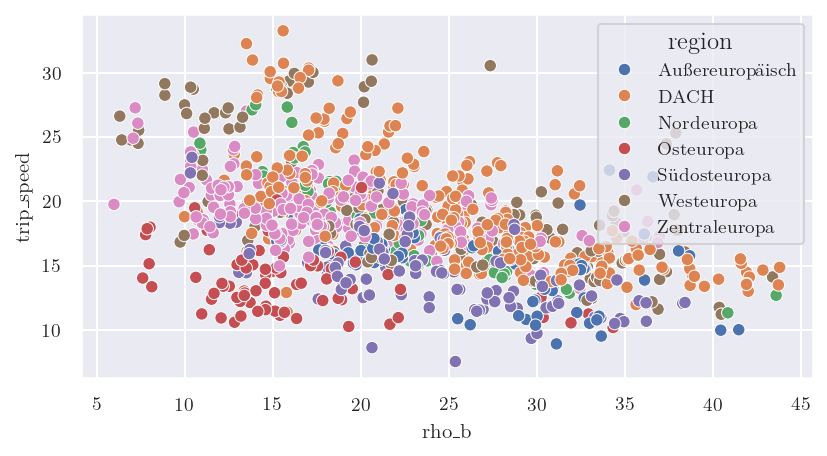

In [35]:
sns.scatterplot(data=data, x='rho_b', y='trip_speed',hue='region', hue_order=order)

In [36]:
curvature_min_max=[min(data['curvature']), max(data['curvature'])]
for val in curvature_min_max:
    fig, ax = plt.subplots()
    df_res=data[data.curvature==val].to_crs('EPSG:3857')
    xmin, ymin, xmax, ymax = da.square_bounds(df_res, padding=0.1)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    df_res.plot(color='r', ax=ax)
    da.add_alidade_smooth(ax, crs=df_res.crs)
    ax.set_axis_off()
    filename='curvature_comparison_'+str(val)+'.png'
    fig.savefig(da.RESULTS_DIR/filename, dpi=300, bbox_inches='tight')
    plt.close(fig)


In [37]:
city_net=data.dissolve(by='machine_readable')
list_length=[]
for idx in city_net.index:
    length_i=city_net.loc[[idx]].to_crs(crs=city_net.loc[[idx]].estimate_utm_crs()).length/2
    list_length.append(length_i.values[0])
city_net['net_length']=list_length

/tmp/ipykernel_33617/3771472443.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(axs.get_xticklabels(), rotation=90)


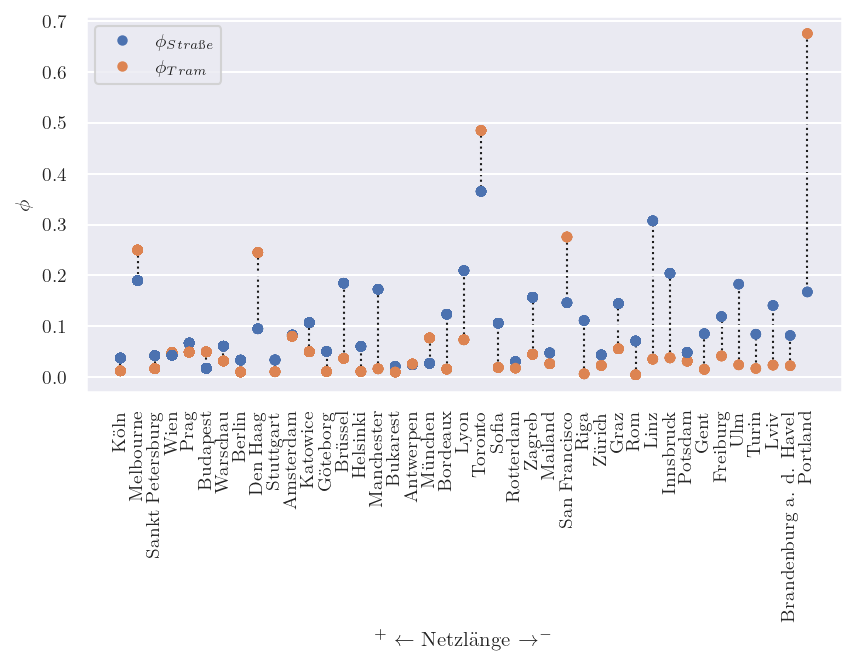

In [56]:
#sns.set_style("darkgrid")
fig, axs = plt.subplots(1,1, figsize=(6.5,3.25))
df_orientation_long = data.melt(['Stadt','machine_readable'], value_vars=['phi_street', 'phi_tram'], var_name='cols')
df_orientation_long = df_orientation_long.merge(city_net[['net_length']], right_index=True, left_on='machine_readable')
df_orientation_long.sort_values(by='net_length', inplace=True, ascending=False)
sns.stripplot(data=df_orientation_long, x='Stadt', y='value', hue='cols', ax=axs, dodge=False, jitter=0)

# Draw dotted lines between the two points for each Stadt
cities = df_orientation_long['Stadt'].unique()
for i, city in enumerate(cities):
    y_vals = data.loc[data['Stadt'] == city, ['phi_street', 'phi_tram']].values[0]
    axs.plot([i, i], y_vals, color='k', linestyle='dotted', linewidth=1, zorder=0)



axs.set_xticklabels(axs.get_xticklabels(), rotation=90)
axs.set_xlabel(r' $^+\leftarrow$ Netzlänge $\rightarrow ^-$')
axs.set_ylabel(r'$\phi$')
for t, l in zip(axs.get_legend().texts, [r'$\phi_{Straße}$', r'$\phi_{Tram}$']):
    t.set_text(l)
axs.get_legend().set_title('')
#axs.set_ylim(0,1)
fig.savefig(da.RESULTS_DIR/'orientations_comp.pdf', dpi=300, bbox_inches='tight')

(0.0, 0.38257205618829515)

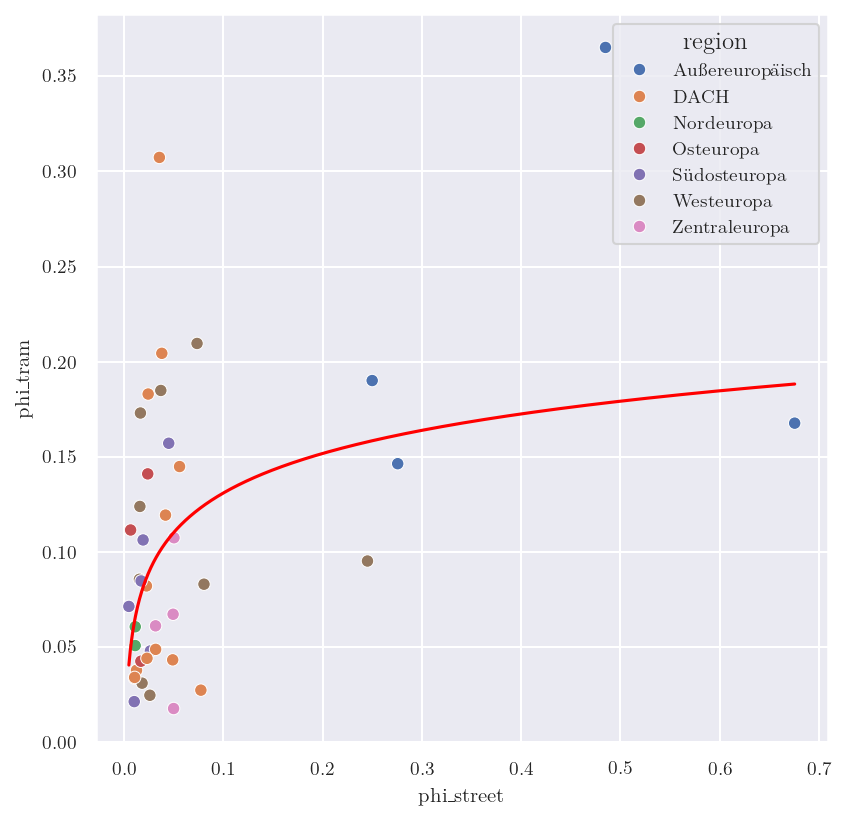

In [39]:
x_ax='phi_street'
y_ax='phi_tram'

data_unabh = city_net[[x_ax]]
x_between = np.linspace(data_unabh.min(), data_unabh.max(), 1000)

def function(x, a, d):
    #y=np.sqrt(a*x)
    #y=a*x+d
    y=a*np.log(x)+d
    #y=np.exp(a*x+c)+d
    return y

# fit = np.polyfit(np.log(data['avg_dist']), data['rho_b'], 1)
# fx = [fit[0]*np.log(x) + fit[1] for x in x_between]

popt, pcov = opt.curve_fit(function, data[x_ax], data[y_ax], maxfev=5000)
popt = np.round(popt, 2)
fx = [function(x, *popt) for x in x_between]

residuals = data[y_ax]- function(data[x_ax], *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((data[y_ax]-np.mean(data[y_ax]))**2)
r_squared = 1 - (ss_res / ss_tot)

fig, axs = plt.subplots(1,1, figsize=(6.3,6.3))
sns.scatterplot(data=df_orientations, x='phi_street', y='phi_tram', ax=axs, hue='region', hue_order=order)
axs.plot(x_between[:, 0], fx, c="red")#, label=label_reg)
#axs.set_xlim(0)
axs.set_ylim(0)
#plt.xscale('log')

In [40]:
r_squared

np.float64(0.17301395191520907)

In [41]:
desc = data[['distance', 'curvature', 'height_up', 'height_down', 'trip_speed', 'avg_dist', 'rho_b']].describe().T
desc.rename(da.COLUMN_NAMES_TEX_SHORT, inplace=True)
desc



,count,mean,std,min,25%,50%,75%,max
$l_{Rel}$,1012.0,11.675301,5.758491,1.150896,7.724617,10.906343,14.506108,44.520709
$\bar\gamma$,1012.0,146.223275,66.533436,15.326808,96.756185,136.265705,181.764309,483.888051
$\bar s^{\uparrow}$,1012.0,12.964650,7.340290,3.291302,8.192964,11.189700,15.681806,89.217482
$\bar s^{\downarrow}$,1012.0,13.014234,7.481493,3.087368,8.193079,11.176352,15.807120,87.834918
$\bar V$,1012.0,17.972222,4.130975,7.547809,15.212981,17.659457,20.165640,33.255673
$\bar l_{Hst}$,1012.0,485.591669,149.567188,242.124134,407.965972,462.277778,515.339624,1299.915768
$\rho_B$,1012.0,22.377509,7.708268,5.967341,16.266507,21.578924,27.828860,43.795378
